# Irrigated area for wheat and maize — MIRCA-OS vs ECIRA (2015)

Two independent gridded estimates of **crop-specific irrigated area** are compared
over the `data4simplace` target domain defined in `config.yaml`.

| | MIRCA-OS v0.1 | ECIRA v2.0 |
|---|---|---|
| Product used | Monthly Growing Area Grids, 2015, `ir` | `Crop_IR`, 2015 |
| Native grid | 5 arcmin (~10 km), WGS84, global | 1 km, ETRS89 / LAEA (EPSG:3035), Europe |
| Unit | growing area, **ha per cell** | irrigated area, **ha per cell** (≤ 100) |
| Method | subnational statistics downscaled onto land-cover grids | remote sensing + statistics, EU/EEA |
| Format | NetCDF, `harvested_area(month, lat, lon)` | one GeoTIFF per crop |

## Crops — what can actually be compared

ECIRA carries 16 crop classes and **wheat is not one of them**: its cereal class
`CERE` is *"cereals excluding maize and rice"*. So only maize is a like-for-like
pair; for wheat the notebook builds both comparisons and reports both:

| Pair | MIRCA-OS side | ECIRA side | Nature |
|---|---|---|---|
| **maize** | `Maize` | `LMAIZ` | like-for-like |
| **wheat** | `Wheat_1 + Wheat_2` | `CERE` | ECIRA side is an **upper bound** — it holds all non-maize, non-rice cereals |
| **cereals** | `Wheat + Barley + Rye + Millet + Sorghum` | `CERE` | like-for-like class, the fair test of the cereal signal |

## Two area definitions

MIRCA-OS is monthly, so a single annual number has to be defined. Both are
computed and reported; the **physical** one is the definition ECIRA uses.

- **physical** — `max` over months of the summed sub-crops: land simultaneously
  under the crop. Comparable to ECIRA's irrigated area.
- **harvested** — `sum` over sub-crops of each sub-crop's `max` month: MIRCA-OS's
  own annual harvested-area definition, which double-counts multi-season cropping.

They are identical for maize (one sub-crop) and differ for wheat (two sub-crops).

## Domain

The `config.yaml` grid (0.1°, 17°W–52°E, 34°N–72°N) is the comparison grid. Both
products are regridded onto it **area-conservatively**, so domain totals are
preserved.

ECIRA covers only EU/EEA countries while MIRCA-OS is global, so **MIRCA-OS is
masked to the ECIRA footprint before any analysis** (§4). The footprint is derived
from ECIRA's own `Crop_A` (growing area) layers, and the mask makes the comparison
strictly one-to-one: every map, total, correlation and country figure below
describes the identical set of cells. Without it MIRCA-OS would be credited with
Turkey, Ukraine, Russia and North Africa, which ECIRA never maps.

Two later sections deliberately step outside that view and say so: §9 checks
MIRCA-OS against its own national statistics, and §10 builds a classification for
the whole domain. Both use the unmasked `*_full` fields.

## 1 — Setup

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import yaml
from matplotlib.colors import (BoundaryNorm, LinearSegmentedColormap, ListedColormap,
                               LogNorm, SymLogNorm)
from matplotlib.patches import Patch
from rasterio.features import rasterize
from pyproj import Transformer
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

ERROR 1: PROJ: proj_create_from_database: Open of /home/muduchuru/miniforge3/envs/sdba/share/proj failed


In [2]:
# --- Palette -----------------------------------------------------------------
# Two datasets = two categorical slots, assigned in fixed order and never cycled.
C_MIRCA = "#2a78d6"   # categorical slot 1 (blue)
C_ECIRA = "#eb6834"   # categorical slot 2 (orange)
C_BOTH  = "#1baf7a"   # categorical slot 3 (aqua) - agreement class
INK_1, INK_2, INK_3 = "#0b0b0b", "#52514e", "#8a8880"
SURFACE = "#fcfcfb"

# Sequential: one hue, light -> dark (magnitude).
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)
# Diverging: two poles + neutral gray midpoint (polarity). Never a rainbow.
DIV_BR = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#0d366b", "#256abf", "#6da7ec", "#cde2fb", "#f0efec",
     "#f7c9c9", "#e88686", "#d03b3b", "#8f2020"],
)

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "axes.edgecolor": INK_3,
    "axes.labelcolor": INK_2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": INK_1,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "figure.dpi": 110,
})

In [3]:
# --- Paths -------------------------------------------------------------------
PROJECT_DIR = Path("/data01/FDS/muduchuru/codes/GITHUB/data4simplace")
CONFIG_PATH = PROJECT_DIR / "config.yaml"

MIRCA_DIR = Path(
    "/data01/FDS/muduchuru/Land/MIRCA-OS/data/contents/"
    "Monthly Growing Area Grids/Monthly Growing Area Grids/2015"
)
ECIRA_IR_DIR = Path("/data01/FDS/muduchuru/Land/ECIRA/Crop_IR/2015")
ECIRA_A_DIR = Path("/data01/FDS/muduchuru/Land/ECIRA/Crop_A/2015")
NE_ADMIN1 = Path(
    "/home/muduchuru/.local/share/cartopy/shapefiles/natural_earth/cultural/"
    "ne_10m_admin_1_states_provinces_lakes.shp"
)

YEAR = 2015
OUT_DIR = PROJECT_DIR / "notebooks" / "outputs" / "irrigation_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

for p in (CONFIG_PATH, MIRCA_DIR, ECIRA_IR_DIR, ECIRA_A_DIR):
    assert p.exists(), f"missing: {p}"
print("output dir:", OUT_DIR)

output dir: /data01/FDS/muduchuru/codes/GITHUB/data4simplace/notebooks/outputs/irrigation_comparison


## 2 — Target grid from `config.yaml`

In [4]:
with CONFIG_PATH.open() as fh:
    CFG = yaml.safe_load(fh)

GRID = CFG["grid"]
RES = float(GRID["resolution_deg"])
LON_MIN, LON_MAX = float(GRID["min_lon"]), float(GRID["max_lon"])
LAT_MIN, LAT_MAX = float(GRID["min_lat"]), float(GRID["max_lat"])

# Cell edges (ascending) and centres of the comparison grid.
LON_EDGES = np.arange(LON_MIN, LON_MAX + RES / 2, RES)
LAT_EDGES = np.arange(LAT_MIN, LAT_MAX + RES / 2, RES)
LON = (LON_EDGES[:-1] + LON_EDGES[1:]) / 2
LAT = (LAT_EDGES[:-1] + LAT_EDGES[1:]) / 2
NLON, NLAT = LON.size, LAT.size

EARTH_R_KM = 6371.0088


def cell_area_km2(lon_edges: np.ndarray, lat_edges: np.ndarray) -> np.ndarray:
    """True spherical area of each (lat, lon) cell, km^2."""
    dlon = np.deg2rad(np.diff(lon_edges))
    dsin = np.diff(np.sin(np.deg2rad(lat_edges)))
    return EARTH_R_KM**2 * dsin[:, None] * dlon[None, :]


AREA_KM2 = cell_area_km2(LON_EDGES, LAT_EDGES)
AREA_HA = AREA_KM2 * 100.0

print(f"grid: {NLAT} lat x {NLON} lon = {NLAT * NLON:,} cells at {RES} deg")
print(f"domain: {LON_MIN} .. {LON_MAX} E, {LAT_MIN} .. {LAT_MAX} N")
print(f"cell area: {AREA_KM2.min():.1f} km2 (north) .. {AREA_KM2.max():.1f} km2 (south)")

grid: 380 lat x 690 lon = 262,200 cells at 0.1 deg
domain: -17.0 .. 52.0 E, 34.0 .. 72.0 N
cell area: 38.3 km2 (north) .. 102.4 km2 (south)


## 3 — Regridding

Both products carry an **extensive** quantity (hectares per cell), so regridding
must *conserve the sum*, not average values.

**MIRCA-OS (regular lon/lat → regular lon/lat).** Exact conservative remapping by
separable 1-D overlap weights: the fraction of each source cell's extent falling
in each target cell, applied along latitude and longitude. Area within a source
cell is assumed uniform, which is the only assumption available at 5 arcmin.

> The MIRCA-OS NetCDF coordinates are **corner-registered**, not centres: longitude
> runs to exactly `180.0` and latitude to exactly `-90.0` over 4320 × 2160 cells, so
> the stored value is each cell's east/south edge. Left uncorrected this offsets the
> grid by half a cell (~4.6 km) — half a target cell. The loader shifts it.

**ECIRA (projected 1 km → regular lon/lat).** Each 1 km pixel centre is transformed
to lon/lat once and binned into the target cell containing it. A pixel's hectares
are never split, so the domain total is conserved exactly; the only error is the
≤ 0.5 km displacement of pixels straddling a target-cell edge, which is small
against the ~8 × 11 km target cell.

In [5]:
def overlap_weights(src_edges: np.ndarray, tgt_edges: np.ndarray) -> np.ndarray:
    """Fraction of each source cell's 1-D extent falling in each target cell.

    Both edge vectors must be strictly increasing. Returns (n_src, n_tgt).
    """
    lo = np.maximum(src_edges[:-1, None], tgt_edges[None, :-1])
    hi = np.minimum(src_edges[1:, None], tgt_edges[None, 1:])
    overlap = np.clip(hi - lo, 0.0, None)
    return overlap / np.diff(src_edges)[:, None]


def conservative_regrid(
    values: np.ndarray,
    src_lat: np.ndarray,
    src_lon: np.ndarray,
    tgt_lat_edges: np.ndarray = LAT_EDGES,
    tgt_lon_edges: np.ndarray = LON_EDGES,
) -> np.ndarray:
    """Area-conservatively remap an extensive (lat, lon) field onto the target grid.

    ``src_lat``/``src_lon`` are cell centres of a regular grid, either direction.
    """
    lat, lon = np.asarray(src_lat, float), np.asarray(src_lon, float)
    arr = np.nan_to_num(np.asarray(values, float))

    if lat[0] > lat[-1]:                      # make latitude ascending
        lat, arr = lat[::-1], arr[::-1, :]
    if lon[0] > lon[-1]:
        lon, arr = lon[::-1], arr[:, ::-1]

    dlat, dlon = np.diff(lat).mean(), np.diff(lon).mean()
    lat_edges = np.append(lat - dlat / 2, lat[-1] + dlat / 2)
    lon_edges = np.append(lon - dlon / 2, lon[-1] + dlon / 2)

    w_lat = overlap_weights(lat_edges, tgt_lat_edges)   # (n_src_lat, n_tgt_lat)
    w_lon = overlap_weights(lon_edges, tgt_lon_edges)
    return w_lat.T @ arr @ w_lon


def _sanity_conservation(before: float, after: float, name: str, tol: float = 1e-3) -> None:
    """Report how much of the source total survived the remap onto the target grid."""
    if before <= 0:
        print(f"  -- {name}: no area in the domain")
        return
    err = abs(after - before) / before
    flag = "OK " if err < tol else "~~ "
    print(f"  {flag}{name}: source {before / 1e3:>9,.1f} kha -> target "
          f"{after / 1e3:>9,.1f} kha  ({err:+.3%} at the domain edge)")

In [6]:
MIRCA_HALF_CELL_FIX = True  # NetCDF coords are cell corners, not centres


def open_mirca(crop_file: str) -> xr.DataArray:
    """Open one MIRCA-OS monthly growing-area file, cropped to the domain.

    Returns ``harvested_area(month, latitude, longitude)`` in ha, months sorted
    1..12 and coordinates corrected to cell centres.
    """
    path = MIRCA_DIR / crop_file
    ds = xr.open_dataset(path)
    da = ds["harvested_area"].sortby("month")

    if MIRCA_HALF_CELL_FIX:
        dlon = float(np.diff(da.longitude.values).mean())
        dlat = float(np.diff(da.latitude.values).mean())   # negative (descending)
        da = da.assign_coords(
            longitude=da.longitude - dlon / 2,
            latitude=da.latitude - dlat / 2,
        )

    pad = 0.5
    lat_slice = (
        slice(LAT_MAX + pad, LAT_MIN - pad)
        if da.latitude[0] > da.latitude[-1]
        else slice(LAT_MIN - pad, LAT_MAX + pad)
    )
    return da.sel(longitude=slice(LON_MIN - pad, LON_MAX + pad), latitude=lat_slice).load()


def mirca_annual(crop_files: list[str]) -> dict[str, np.ndarray]:
    """Annual irrigated area on the target grid, both definitions, ha per cell.

    ``physical``  = max over months of the summed sub-crops (land at one time).
    ``harvested`` = sum over sub-crops of each sub-crop's max month (MIRCA's own
                    annual harvested area; double-counts multiple cropping).
    """
    monthly_sum, harvested, coords = None, None, None
    for fname in crop_files:
        da = open_mirca(fname)
        coords = (da.latitude.values, da.longitude.values)
        vals = np.nan_to_num(da.values)                    # (month, lat, lon)
        monthly_sum = vals if monthly_sum is None else monthly_sum + vals
        peak = vals.max(axis=0)
        harvested = peak if harvested is None else harvested + peak

    physical = monthly_sum.max(axis=0)
    lat, lon = coords

    # The source was read with a padding ring, so score conservation against the
    # source cells whose centres actually fall inside the domain.
    inside = (
        ((lat >= LAT_MIN) & (lat <= LAT_MAX))[:, None]
        & ((lon >= LON_MIN) & (lon <= LON_MAX))[None, :]
    )

    out = {}
    for name, field in (("physical", physical), ("harvested", harvested)):
        grid = conservative_regrid(field, lat, lon)
        _sanity_conservation(float(field[inside].sum()), float(grid.sum()),
                             f"{name:9s}", tol=0.02)
        out[name] = grid
    return out

In [7]:
class EciraRegridder:
    """Maps ECIRA's 1 km EPSG:3035 pixels onto the target grid once, then reuses it.

    The flat target-cell index of every source pixel is precomputed, so regridding
    a raster is a single ``bincount``. Hectares are never split across cells, so
    domain totals are conserved exactly.
    """

    def __init__(self, template: Path, block_rows: int = 512) -> None:
        with rasterio.open(template) as src:
            self.shape = (src.height, src.width)
            transform, crs = src.transform, src.crs

        to_wgs84 = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        flat_index = np.full(self.shape, -1, dtype=np.int32)
        cols = np.arange(self.shape[1])

        a, b, c, d, e, f = (transform.a, transform.b, transform.c,
                            transform.d, transform.e, transform.f)
        for r0 in range(0, self.shape[0], block_rows):
            r1 = min(r0 + block_rows, self.shape[0])
            rows = np.arange(r0, r1)
            cc, rr = np.meshgrid(cols + 0.5, rows + 0.5)   # pixel centres
            x = c + a * cc + b * rr
            y = f + d * cc + e * rr
            lon, lat = to_wgs84.transform(x.ravel(), y.ravel())

            ix = np.searchsorted(LON_EDGES, lon, side="right") - 1
            iy = np.searchsorted(LAT_EDGES, lat, side="right") - 1
            inside = (ix >= 0) & (ix < NLON) & (iy >= 0) & (iy < NLAT)
            idx = np.where(inside, iy * NLON + ix, -1).astype(np.int32)
            flat_index[r0:r1, :] = idx.reshape(r1 - r0, self.shape[1])

        self.flat_index = flat_index.ravel()
        self.valid = self.flat_index >= 0
        print(f"  ECIRA pixels inside the domain: {self.valid.sum():,} / {self.valid.size:,}")

    def regrid(self, path: Path, label: str | None = None) -> np.ndarray:
        with rasterio.open(path) as src:
            arr = src.read(1).astype("float64").ravel()
        arr = np.nan_to_num(arr)
        keep = self.valid & (arr != 0)
        grid = np.bincount(
            self.flat_index[keep], weights=arr[keep], minlength=NLAT * NLON
        ).reshape(NLAT, NLON)
        if label:
            _sanity_conservation(float(arr[self.valid].sum()), float(grid.sum()), label)
        return grid

    def coverage_mask(self, paths: list[Path]) -> np.ndarray:
        """Target cells holding at least one ECIRA pixel with a growing area > 0."""
        total = np.zeros(NLAT * NLON)
        for p in paths:
            with rasterio.open(p) as src:
                arr = np.nan_to_num(src.read(1).astype("float64")).ravel()
            keep = self.valid & (arr > 0)
            total += np.bincount(self.flat_index[keep], weights=arr[keep],
                                 minlength=NLAT * NLON)
        return (total > 0).reshape(NLAT, NLON)

## 4 — Load and regrid

In [8]:
MIRCA_CROPS = {
    "maize": ["Maize"],
    "wheat": ["Wheat_1", "Wheat_2"],
    # ECIRA's CERE class = cereals excluding maize and rice.
    "cereals": ["Wheat_1", "Wheat_2", "Barley", "Rye", "Millet", "Sorghum"],
}


def mirca_files(stems: list[str], system: str) -> list[str]:
    """File names for a crop group under the irrigated ('ir') or rainfed ('rf') system."""
    return [f"MIRCA-OS_{stem}_{YEAR}_{system}.nc" for stem in stems]


mirca = {}
for crop, stems in MIRCA_CROPS.items():
    print(f"MIRCA-OS {crop} irrigated ({len(stems)} file(s))")
    mirca[crop] = mirca_annual(mirca_files(stems, "ir"))

MIRCA-OS maize irrigated (1 file(s))


  OK physical : source   3,007.5 kha -> target   3,007.5 kha  (+0.000% at the domain edge)


  OK harvested: source   3,007.5 kha -> target   3,007.5 kha  (+0.000% at the domain edge)
MIRCA-OS wheat irrigated (2 file(s))


  OK physical : source   2,081.7 kha -> target   2,081.7 kha  (+0.000% at the domain edge)


  OK harvested: source   2,081.7 kha -> target   2,081.7 kha  (+0.000% at the domain edge)
MIRCA-OS cereals irrigated (6 file(s))


  OK physical : source   2,795.8 kha -> target   2,795.8 kha  (+0.000% at the domain edge)


  OK harvested: source   3,081.5 kha -> target   3,081.5 kha  (+0.000% at the domain edge)


In [9]:
ECIRA_CROPS = {"maize": "LMAIZ_IR_A_2015.tif", "cereals": "CERE_IR_A_2015.tif"}

regridder = EciraRegridder(ECIRA_IR_DIR / ECIRA_CROPS["maize"])

ecira = {}
for crop, fname in ECIRA_CROPS.items():
    print(f"ECIRA {crop}")
    ecira[crop] = regridder.regrid(ECIRA_IR_DIR / fname, label=f"{crop:9s}")

# ECIRA has no wheat class; CERE is the only cereal container it offers.
ecira["wheat"] = ecira["cereals"]

  ECIRA pixels inside the domain: 14,638,064 / 15,244,880
ECIRA maize


  OK maize    : source   2,291.2 kha -> target   2,291.2 kha  (+0.000% at the domain edge)
ECIRA cereals


  OK cereals  : source   1,416.0 kha -> target   1,416.0 kha  (+0.000% at the domain edge)


In [10]:
# ECIRA coverage footprint: cells where ECIRA reports any crop growing area.
# Everything outside is unmapped by ECIRA, not zero, and must not be scored.
coverage = regridder.coverage_mask(sorted(ECIRA_A_DIR.glob("*_A_2015.tif")))
print(f"ECIRA coverage: {coverage.sum():,} of {NLAT * NLON:,} target cells "
      f"({100 * coverage.mean():.1f}%)")

ECIRA coverage: 52,819 of 262,200 target cells (20.1%)


In [11]:
# Country index raster (Natural Earth admin-1 dissolved to admin-0), used for the
# per-country breakdown. Read offline from the cartopy data cache.
adm = gpd.read_file(NE_ADMIN1, columns=["admin", "geometry"])
adm = adm.dissolve(by="admin", as_index=False)
adm = adm.cx[LON_MIN:LON_MAX, LAT_MIN:LAT_MAX]

COUNTRY_NAMES = sorted(adm["admin"].tolist())
country_id = {name: i + 1 for i, name in enumerate(COUNTRY_NAMES)}

country_grid = rasterize(
    ((geom, country_id[name]) for name, geom in zip(adm["admin"], adm.geometry)),
    out_shape=(NLAT, NLON),
    transform=rasterio.transform.from_origin(LON_MIN, LAT_MAX, RES, RES),
    fill=0,
    dtype="int32",
)[::-1, :]  # rasterize writes north-up; our grid is south-up
print(f"{len(COUNTRY_NAMES)} countries rasterised onto the target grid")

67 countries rasterised onto the target grid


### Masking MIRCA-OS to the ECIRA footprint

MIRCA-OS is global and ECIRA stops at the EU/EEA border, so the two are put on
**exactly the same cells before anything is computed**: every MIRCA-OS field is
blanked outside the ECIRA footprint. Maps, totals, correlations and the country
table then all describe one identical cell set, and no figure can suggest a
disagreement that is really just ECIRA not reaching that far.

The unmasked fields are kept alongside as `*_full`, because two questions
genuinely need MIRCA-OS's own global view rather than the comparison view: how
much area the mask removes (below), and §9's check of MIRCA-OS against its own
national input statistics.

In [12]:
PAIRS = {
    "maize":   ("Maize",   "MIRCA-OS Maize",             "ECIRA LMAIZ (maize)",              "like-for-like"),
    "wheat":   ("Wheat",   "MIRCA-OS Wheat (2 seasons)", "ECIRA CERE (all cereals ex maize/rice)", "ECIRA side is an upper bound"),
    "cereals": ("Cereals", "MIRCA-OS Wheat+Barley+Rye+Millet+Sorghum", "ECIRA CERE", "like-for-like class"),
}

APPLY_ECIRA_MASK = True   # blank MIRCA-OS outside the ECIRA footprint, up front


def to_footprint(field: np.ndarray) -> np.ndarray:
    """Blank a MIRCA-OS field outside the ECIRA footprint.

    Zero, not NaN: the cell is genuinely excluded from the comparison, and every
    downstream sum, correlation and map then treats both products identically.
    """
    return np.where(coverage, field, 0.0) if APPLY_ECIRA_MASK else field


data_vars = {"cell_area_ha": (("lat", "lon"), AREA_HA),
             "ecira_coverage": (("lat", "lon"), coverage.astype("int8")),
             "country_id": (("lat", "lon"), country_grid)}
for crop in PAIRS:
    for defn in ("physical", "harvested"):
        suffix = "" if defn == "physical" else "_harvested"
        data_vars[f"mirca_{crop}{suffix}"] = (("lat", "lon"),
                                              to_footprint(mirca[crop][defn]))
        data_vars[f"mirca_{crop}{suffix}_full"] = (("lat", "lon"), mirca[crop][defn])
    data_vars[f"ecira_{crop}"] = (("lat", "lon"), ecira[crop])

ds = xr.Dataset(data_vars, coords={"lat": LAT, "lon": LON})
for crop in PAIRS:
    ds[f"mirca_{crop}"].attrs = {"units": "ha", "definition": "max monthly growing area (physical)",
                                 "masked_to": "ECIRA footprint"}
    ds[f"mirca_{crop}_harvested"].attrs = {"units": "ha", "definition": "sum of sub-crop max months (harvested)",
                                           "masked_to": "ECIRA footprint"}
    ds[f"mirca_{crop}_full"].attrs = {"units": "ha", "definition": "physical, unmasked"}
    ds[f"mirca_{crop}_harvested_full"].attrs = {"units": "ha", "definition": "harvested, unmasked"}
    ds[f"ecira_{crop}"].attrs = {"units": "ha", "definition": "annual irrigated area"}

removed = {PAIRS[c][0]: (ds[f"mirca_{c}_full"].values.sum()
                         - ds[f"mirca_{c}"].values.sum()) / 1e3 for c in PAIRS}
print("MIRCA-OS area removed by the ECIRA footprint mask (kha):")
for k, v in removed.items():
    print(f"  {k:9s} {v:9,.0f}")

ds["ecira_coverage"].attrs = {"long_name": "1 where ECIRA maps any crop growing area"}
ds["country_id"].attrs = {"long_name": "index into the country_names attribute, 0 = none"}
ds.attrs = {
    "title": f"Irrigated area {YEAR}: MIRCA-OS vs ECIRA on the data4simplace grid",
    "grid": f"{RES} deg, {LON_MIN}..{LON_MAX}E, {LAT_MIN}..{LAT_MAX}N",
    "mirca_source": str(MIRCA_DIR),
    "ecira_source": str(ECIRA_IR_DIR),
    "country_names": "|".join(COUNTRY_NAMES),
    "note": "ECIRA has no wheat class; ecira_wheat is a copy of ecira_cereals (CERE).",
}
ds

MIRCA-OS area removed by the ECIRA footprint mask (kha):
  Maize           920
  Wheat         1,726
  Cereals       2,139


<xarray.Dataset> Size: 35MB
Dimensions:                       (lat: 380, lon: 690)
Coordinates:
  * lat                           (lat) float64 3kB 34.05 34.15 ... 71.85 71.95
  * lon                           (lon) float64 6kB -16.95 -16.85 ... 51.95
Data variables: (12/18)
    cell_area_ha                  (lat, lon) float64 2MB 1.024e+04 ... 3.831e+03
    ecira_coverage                (lat, lon) int8 262kB 0 0 0 0 0 ... 0 0 0 0 0
    country_id                    (lat, lon) int32 1MB 0 0 0 0 0 ... 55 55 55 55
    mirca_maize                   (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_maize_full              (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_maize_harvested         (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    ...                            ...
    ecira_wheat                   (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_cereals                 (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_cereals_full            (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_cereals_harvested       (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    mirca_cereals_harvested_full  (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
    ecira_cereals                 (lat, lon) float64 2MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    title:          Irrigated area 2015: MIRCA-OS vs ECIRA on the data4simpla...
    grid:           0.1 deg, -17.0..52.0E, 34.0..72.0N
    mirca_source:   /data01/FDS/muduchuru/Land/MIRCA-OS/data/contents/Monthly...
    ecira_source:   /data01/FDS/muduchuru/Land/ECIRA/Crop_IR/2015
    country_names:  Akrotiri Sovereign Base Area|Aland|Albania|Algeria|Andorr...
    note:           ECIRA has no wheat class; ecira_wheat is a copy of ecira_...

## 5 — Domain totals

Everything from here on is the masked, one-to-one comparison. The first column
keeps the unmasked MIRCA-OS total for reference — the gap between it and the
second is the area the mask removed, i.e. the part of the domain ECIRA never
reaches, not a disagreement.

In [13]:
rows = []
for crop, (short, m_lbl, e_lbl, note) in PAIRS.items():
    m_phys = ds[f"mirca_{crop}"].values
    m_harv = ds[f"mirca_{crop}_harvested"].values
    e = ds[f"ecira_{crop}"].values
    rows.append({
        "crop": short,
        "MIRCA unmasked (kha)": ds[f"mirca_{crop}_full"].values.sum() / 1e3,
        "MIRCA masked (kha)": m_phys.sum() / 1e3,
        "MIRCA harvested, masked (kha)": m_harv.sum() / 1e3,
        "ECIRA (kha)": e[coverage].sum() / 1e3,
        "ECIRA - MIRCA (kha)": (e[coverage].sum() - m_phys.sum()) / 1e3,
        "ECIRA / MIRCA": e[coverage].sum() / max(m_phys.sum(), 1e-9),
        "comparison": note,
    })

totals = pd.DataFrame(rows).set_index("crop")
totals.round(1)

,MIRCA unmasked (kha),MIRCA masked (kha),"MIRCA harvested, masked (kha)",ECIRA (kha),ECIRA - MIRCA (kha),ECIRA / MIRCA,comparison
crop,,,,,,,
Maize,3007.5,2087.3,2087.3,2291.2,203.9,1.1,like-for-like
Wheat,2081.7,355.7,355.7,1416.0,1060.3,4.0,ECIRA side is an upper bound
Cereals,2795.8,656.5,792.2,1416.0,759.6,2.2,like-for-like class


In [14]:
print(f"Domain totals, {YEAR}, within the ECIRA footprint")
for label in ("Maize", "Cereals"):
    t = totals.loc[label]
    print(f"  {label.lower():8s} MIRCA-OS {t['MIRCA masked (kha)']:9,.0f} kha"
          f"   ECIRA {t['ECIRA (kha)']:9,.0f} kha"
          f"   ECIRA/MIRCA = {t['ECIRA / MIRCA']:.2f}")

wheat_share = (totals.loc["Wheat", "MIRCA masked (kha)"]
               / totals.loc["Cereals", "MIRCA masked (kha)"])
print(f"\nWheat is {wheat_share:.0%} of MIRCA-OS irrigated cereals in the footprint,")
print("so ECIRA's CERE class is that much of an over-statement when read as wheat.")

outside = totals["MIRCA unmasked (kha)"] - totals["MIRCA masked (kha)"]
print("\nRemoved by the mask — MIRCA-OS area outside the ECIRA footprint (kha):")
print(outside.round(0).to_string())

Domain totals, 2015, within the ECIRA footprint
  maize    MIRCA-OS     2,087 kha   ECIRA     2,291 kha   ECIRA/MIRCA = 1.10
  cereals  MIRCA-OS       656 kha   ECIRA     1,416 kha   ECIRA/MIRCA = 2.16

Wheat is 54% of MIRCA-OS irrigated cereals in the footprint,
so ECIRA's CERE class is that much of an over-statement when read as wheat.

Removed by the mask — MIRCA-OS area outside the ECIRA footprint (kha):
crop
Maize       920.0
Wheat      1726.0
Cereals    2139.0


## 6 — Where each product puts the area

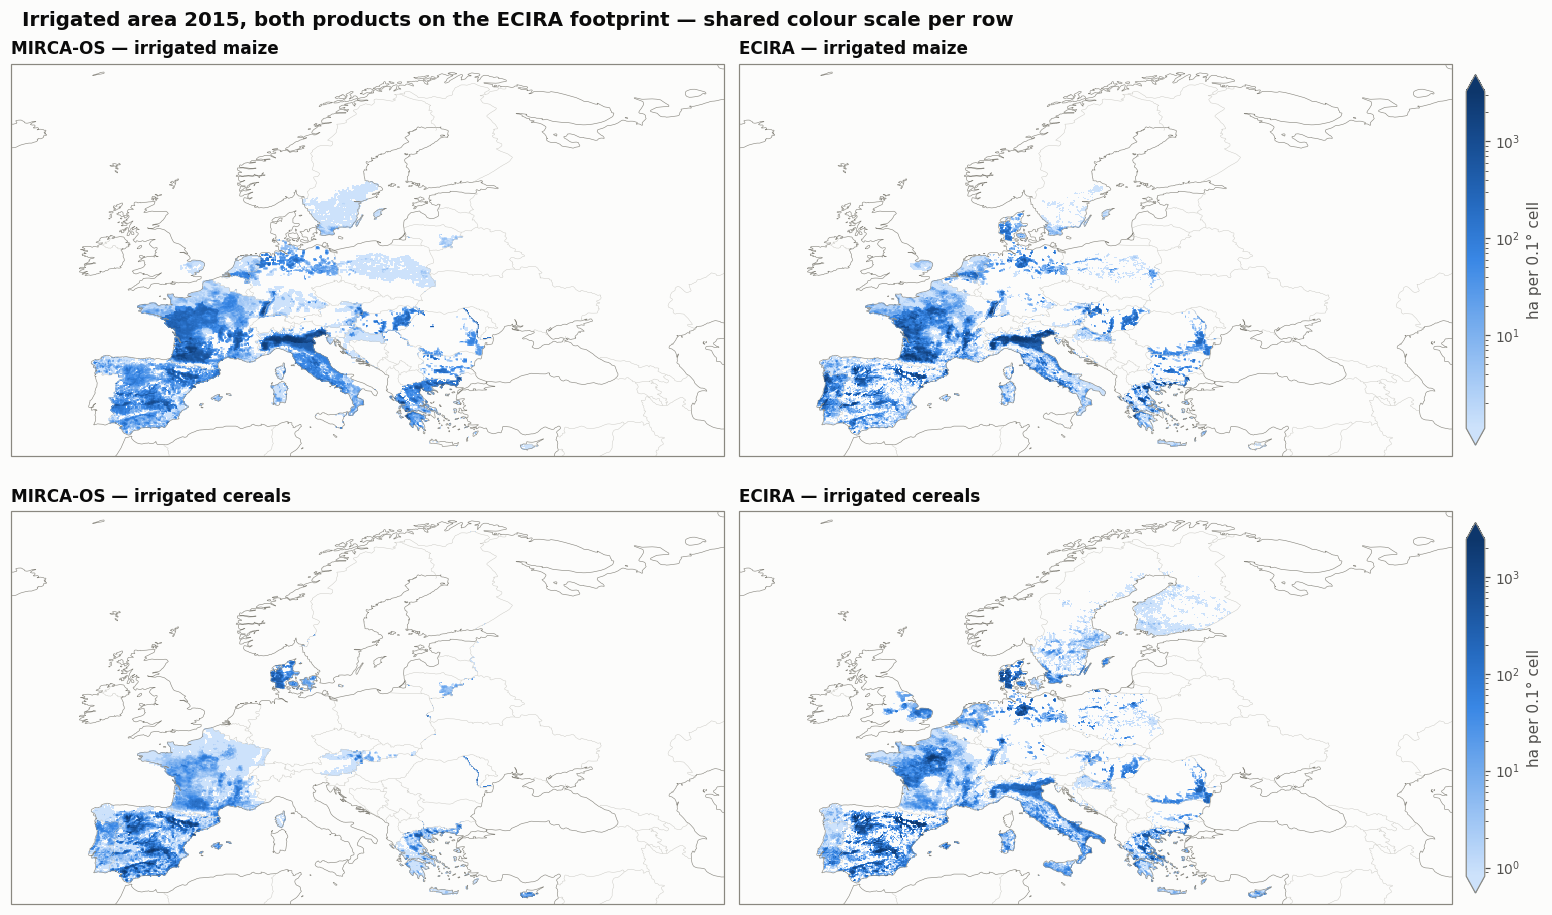

In [15]:
def add_map_frame(ax) -> None:
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.4, edgecolor=INK_3)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.3, edgecolor="#c9c8c2")


def plot_field(ax, field, *, vmin, vmax, cmap=SEQ_BLUE, title="", norm=None):
    data = np.where(field > 0, field, np.nan)
    norm = norm or LogNorm(vmin=vmin, vmax=vmax)
    mesh = ax.pcolormesh(LON_EDGES, LAT_EDGES, data, norm=norm, cmap=cmap,
                         transform=ccrs.PlateCarree(), shading="flat")
    add_map_frame(ax)
    ax.set_title(title, loc="left")
    return mesh


proj = ccrs.PlateCarree()
fig, axes = plt.subplots(2, 2, figsize=(14, 8.4), layout="constrained",
                         subplot_kw={"projection": proj})

for row, crop in enumerate(["maize", "cereals"]):
    m, e = ds[f"mirca_{crop}"].values, ds[f"ecira_{crop}"].values
    vmax = max(np.nanpercentile(m[m > 0], 99.9), np.nanpercentile(e[e > 0], 99.9))
    vmin = vmax / 3e3
    mesh = plot_field(axes[row, 0], m, vmin=vmin, vmax=vmax,
                      title=f"MIRCA-OS — irrigated {crop}")
    plot_field(axes[row, 1], e, vmin=vmin, vmax=vmax,
               title=f"ECIRA — irrigated {crop}")
    cb = fig.colorbar(mesh, ax=axes[row, :], shrink=0.85, pad=0.01, extend="both")
    cb.set_label("ha per 0.1° cell", color=INK_2)

fig.suptitle(f"Irrigated area {YEAR}, both products on the ECIRA footprint "
             "— shared colour scale per row",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.savefig(OUT_DIR / "maps_side_by_side.png", bbox_inches="tight", dpi=150)
plt.show()

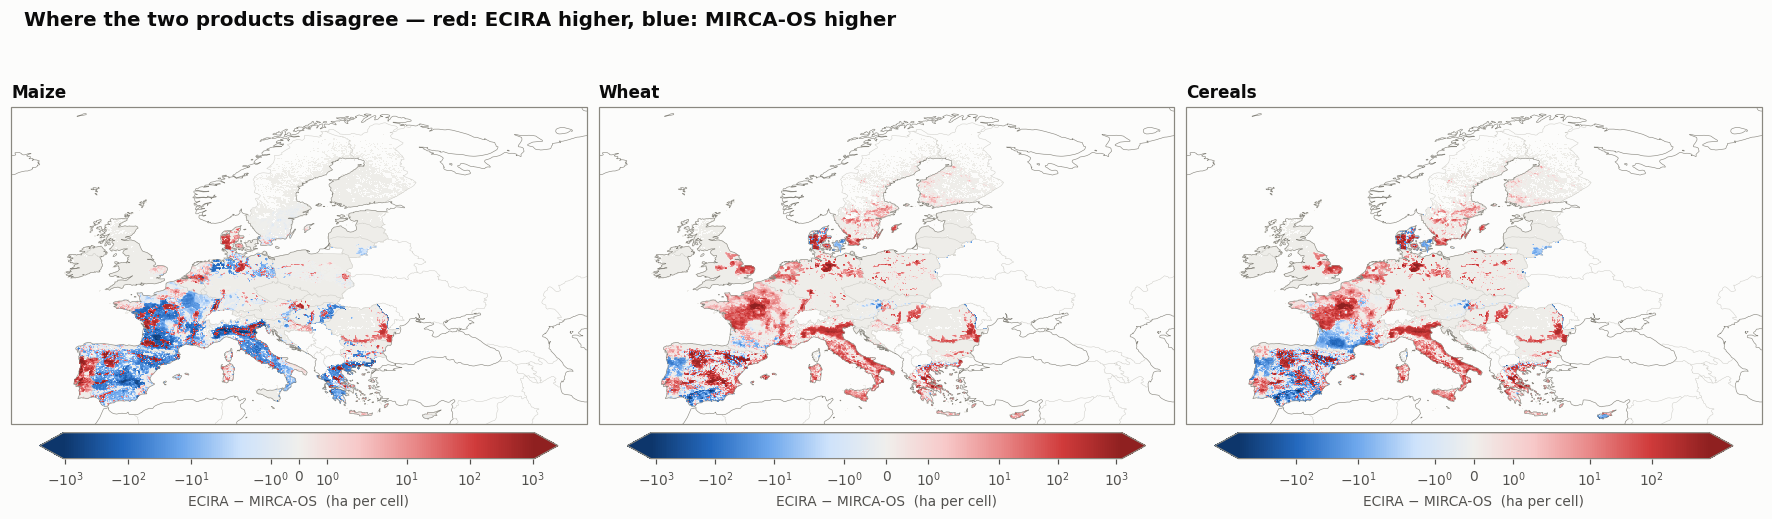

In [16]:
# Difference maps, restricted to the ECIRA footprint: outside it ECIRA is
# unmapped, and painting that as "-MIRCA" would invent a disagreement.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), layout="constrained",
                         subplot_kw={"projection": proj})

BACKDROP = ListedColormap(["#eeede9"])

for ax, crop in zip(axes, PAIRS):
    m = np.where(coverage, ds[f"mirca_{crop}"].values, np.nan)
    e = np.where(coverage, ds[f"ecira_{crop}"].values, np.nan)
    diff = e - m
    finite = np.isfinite(diff) & (diff != 0)

    # The difference is heavy-tailed: a linear scale set by the extremes washes
    # out the bulk of the map, so the arms are log-scaled outside a linear core.
    lim = float(np.nanpercentile(np.abs(diff[finite]), 99.5))
    lin = float(np.nanpercentile(np.abs(diff[finite]), 40))

    # Pale backdrop = the ECIRA footprint, so "white" reads as agreement rather
    # than as unmapped land.
    ax.pcolormesh(LON_EDGES, LAT_EDGES, np.where(coverage, 1.0, np.nan),
                  cmap=BACKDROP, vmin=0, vmax=1, transform=proj,
                  shading="flat", zorder=0)
    mesh = ax.pcolormesh(LON_EDGES, LAT_EDGES, np.where(diff == 0, np.nan, diff),
                         norm=SymLogNorm(linthresh=lin, vmin=-lim, vmax=lim, base=10),
                         cmap=DIV_BR, transform=proj, shading="flat", zorder=1)
    add_map_frame(ax)
    ax.set_title(f"{PAIRS[crop][0]}", loc="left")
    cb = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.02,
                      shrink=0.9, extend="both")
    cb.set_label("ECIRA − MIRCA-OS  (ha per cell)", color=INK_2, fontsize=9)

fig.suptitle("Where the two products disagree — red: ECIRA higher, blue: MIRCA-OS higher",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.savefig(OUT_DIR / "maps_difference.png", bbox_inches="tight", dpi=150)
plt.show()

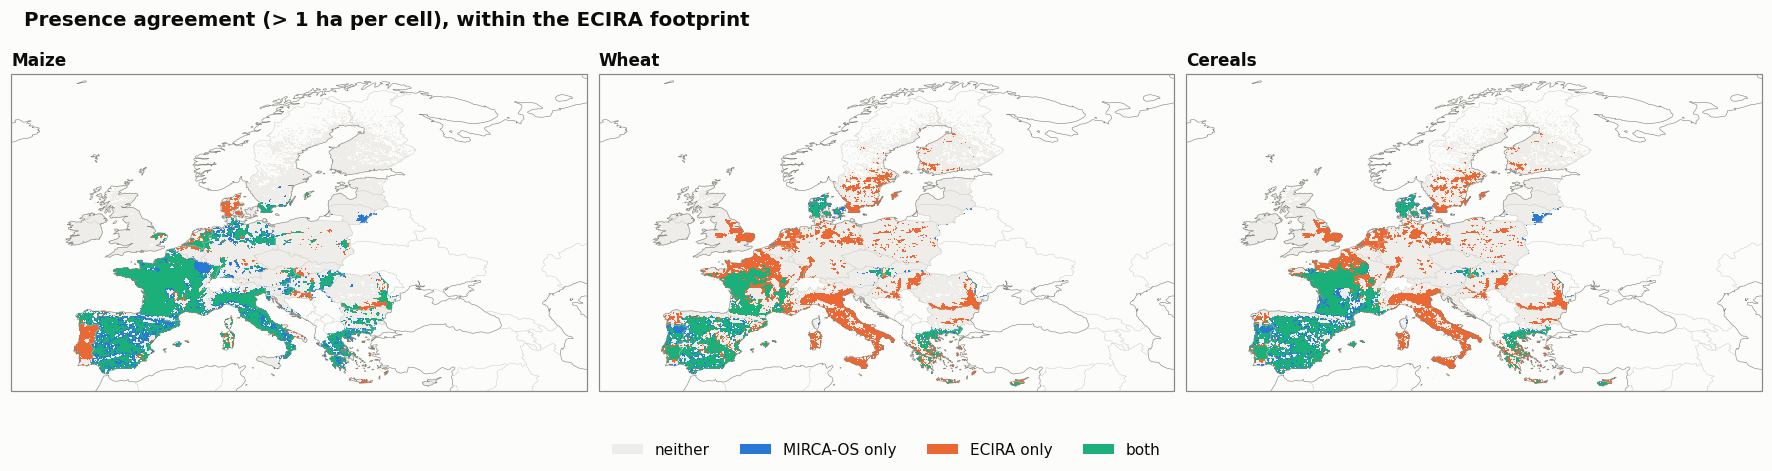

,cells both,MIRCA only,ECIRA only,Jaccard,MIRCA area in ECIRA-blank cells (%),ECIRA area in MIRCA-blank cells (%)
crop,,,,,,
Maize,12899,4847,2455,0.64,4.00,7.33
Wheat,6659,1227,9873,0.37,4.60,25.26
Cereals,7733,2263,8799,0.41,4.09,24.54


In [17]:
# Presence agreement: which product sees irrigation of this crop at all.
# 1 ha per 0.1 deg cell (~0.001% of the cell) is the presence threshold.
PRESENCE_HA = 1.0

agree_cmap = ListedColormap(["#eeede9", C_MIRCA, C_ECIRA, C_BOTH])
labels = ["neither", "MIRCA-OS only", "ECIRA only", "both"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained",
                         subplot_kw={"projection": proj})
agreement_rows = []

for ax, crop in zip(axes, PAIRS):
    m = ds[f"mirca_{crop}"].values > PRESENCE_HA
    e = ds[f"ecira_{crop}"].values > PRESENCE_HA
    cls = np.where(m & e, 3, np.where(e, 2, np.where(m, 1, 0))).astype(float)
    cls[~coverage] = np.nan

    ax.pcolormesh(LON_EDGES, LAT_EDGES, cls, cmap=agree_cmap,
                  norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
                  transform=proj, shading="flat")
    add_map_frame(ax)
    ax.set_title(PAIRS[crop][0], loc="left")

    mm, ee = m & coverage, e & coverage
    both, only_m, only_e = (mm & ee).sum(), (mm & ~ee).sum(), (ee & ~mm).sum()
    agreement_rows.append({
        "crop": PAIRS[crop][0],
        "cells both": both, "MIRCA only": only_m, "ECIRA only": only_e,
        "Jaccard": both / max(both + only_m + only_e, 1),
        "MIRCA area in ECIRA-blank cells (%)":
            100 * ds[f"mirca_{crop}"].values[mm & ~ee].sum()
            / max(ds[f"mirca_{crop}"].values[mm].sum(), 1e-9),
        "ECIRA area in MIRCA-blank cells (%)":
            100 * ds[f"ecira_{crop}"].values[ee & ~mm].sum()
            / max(ds[f"ecira_{crop}"].values[ee].sum(), 1e-9),
    })

handles = [Patch(facecolor=c, edgecolor="none", label=l)
           for c, l in zip(agree_cmap.colors, labels)]
fig.legend(handles=handles, loc="outside lower center", ncol=4)
fig.suptitle(f"Presence agreement (> {PRESENCE_HA:.0f} ha per cell), within the ECIRA footprint",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.savefig(OUT_DIR / "maps_agreement.png", bbox_inches="tight", dpi=150)
plt.show()

agreement = pd.DataFrame(agreement_rows).set_index("crop")
agreement.round(2)

## 7 — Cell-level agreement

In [18]:
def pair_metrics(crop: str) -> dict:
    m = ds[f"mirca_{crop}"].values[coverage]
    e = ds[f"ecira_{crop}"].values[coverage]
    both = (m > 0) | (e > 0)
    m_b, e_b = m[both], e[both]
    return {
        "crop": PAIRS[crop][0],
        "n cells (either > 0)": int(both.sum()),
        "MIRCA total (kha)": m.sum() / 1e3,
        "ECIRA total (kha)": e.sum() / 1e3,
        "bias (kha)": (e.sum() - m.sum()) / 1e3,
        "bias (%)": 100 * (e.sum() - m.sum()) / max(m.sum(), 1e-9),
        "MAE (ha/cell)": np.abs(e_b - m_b).mean(),
        "RMSE (ha/cell)": np.sqrt(((e_b - m_b) ** 2).mean()),
        "Pearson r": np.corrcoef(m_b, e_b)[0, 1],
        "Pearson r (log1p)": np.corrcoef(np.log1p(m_b), np.log1p(e_b))[0, 1],
        "Spearman rho": spearmanr(m_b, e_b).statistic,
    }


metrics = pd.DataFrame([pair_metrics(c) for c in PAIRS]).set_index("crop")
metrics.round(3)

,n cells (either > 0),MIRCA total (kha),ECIRA total (kha),bias (kha),bias (%),MAE (ha/cell),RMSE (ha/cell),Pearson r,Pearson r (log1p),Spearman rho
crop,,,,,,,,,,
Maize,27121,2087.274,2291.218,203.944,9.771,51.766,160.691,0.835,0.721,0.598
Wheat,25996,355.708,1416.019,1060.312,298.085,46.409,170.602,0.580,0.534,0.259
Cereals,26695,656.450,1416.019,759.569,115.709,38.457,130.478,0.779,0.527,0.234


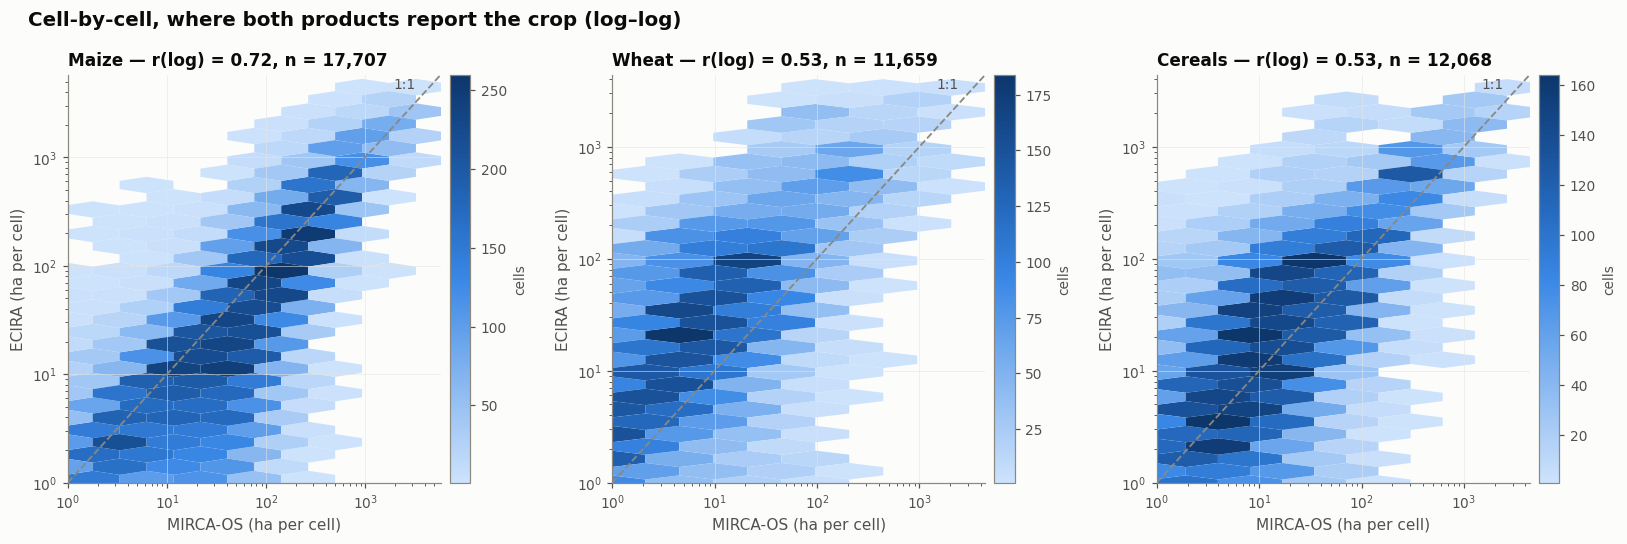

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0))

for ax, crop in zip(axes, PAIRS):
    m = ds[f"mirca_{crop}"].values[coverage]
    e = ds[f"ecira_{crop}"].values[coverage]
    sel = (m > 0) & (e > 0)
    hb = ax.hexbin(m[sel], e[sel], gridsize=45, xscale="log", yscale="log",
                   mincnt=1, cmap=SEQ_BLUE, linewidths=0)
    lim = [1e0, max(m.max(), e.max()) * 1.3]
    ax.plot(lim, lim, color=INK_3, lw=1.2, ls="--", zorder=3)
    ax.text(lim[1] * 0.55, lim[1] * 0.95, "1:1", color=INK_2, fontsize=9,
            ha="right", va="top")
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
           xlabel="MIRCA-OS (ha per cell)", ylabel="ECIRA (ha per cell)")
    r = metrics.loc[PAIRS[crop][0], "Pearson r (log1p)"]
    n_both = int(sel.sum())
    ax.set_title(f"{PAIRS[crop][0]} — r(log) = {r:.2f}, n = {n_both:,}", loc="left")
    ax.grid(True, which="major", alpha=0.6)
    cb = fig.colorbar(hb, ax=ax, pad=0.02)
    cb.set_label("cells", color=INK_2, fontsize=9)

fig.suptitle("Cell-by-cell, where both products report the crop (log–log)",
             x=0.02, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(OUT_DIR / "scatter_cell_level.png", bbox_inches="tight", dpi=150)
plt.show()

### Does the disagreement survive aggregation?

Cell-level correlation at 0.1° mixes a genuine disagreement about *how much* with
a mere disagreement about *exactly where*. Aggregating both fields into coarser
blocks removes the second: if `r` climbs steeply with scale, the products largely
agree on regional totals and differ only in placement.

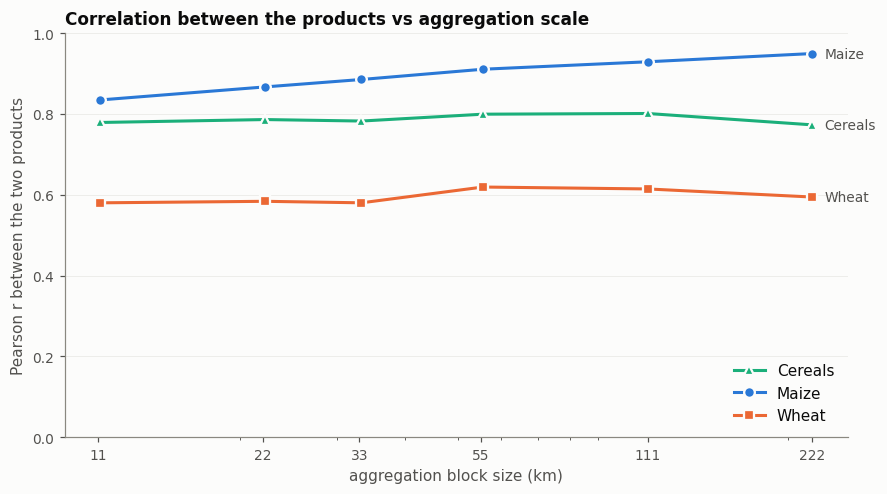

crop,Cereals,Maize,Wheat
approx_km,,,
11.1,0.779,0.835,0.580
22.2,0.786,0.867,0.584
33.3,0.782,0.885,0.580
55.5,0.799,0.911,0.619
111.0,0.801,0.929,0.614
222.0,0.773,0.950,0.594


In [20]:
def block_sum(field: np.ndarray, k: int) -> np.ndarray:
    ny, nx = (field.shape[0] // k) * k, (field.shape[1] // k) * k
    return field[:ny, :nx].reshape(ny // k, k, nx // k, k).sum(axis=(1, 3))


FACTORS = [1, 2, 3, 5, 10, 20]
scale_rows = []
for crop in PAIRS:
    m_full = np.where(coverage, ds[f"mirca_{crop}"].values, 0.0)
    e_full = np.where(coverage, ds[f"ecira_{crop}"].values, 0.0)
    for k in FACTORS:
        m_k, e_k = block_sum(m_full, k), block_sum(e_full, k)
        sel = (m_k > 0) | (e_k > 0)
        scale_rows.append({
            "crop": PAIRS[crop][0], "factor": k, "resolution_deg": k * RES,
            "approx_km": k * RES * 111,
            "r": np.corrcoef(m_k[sel], e_k[sel])[0, 1],
            "n": int(sel.sum()),
        })

scale = pd.DataFrame(scale_rows)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
markers = {"Maize": "o", "Wheat": "s", "Cereals": "^"}
colors = {"Maize": C_MIRCA, "Wheat": C_ECIRA, "Cereals": C_BOTH}
for crop_lbl, grp in scale.groupby("crop"):
    ax.plot(grp["approx_km"], grp["r"], marker=markers[crop_lbl], ms=7,
            color=colors[crop_lbl], label=crop_lbl,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    last = grp.iloc[-1]
    ax.annotate(crop_lbl, (last["approx_km"], last["r"]), textcoords="offset points",
                xytext=(8, 0), va="center", color=INK_2, fontsize=9)
ax.set(xscale="log", xlabel="aggregation block size (km)",
       ylabel="Pearson r between the two products", ylim=(0, 1))
ax.set_xticks([11, 22, 33, 55, 111, 222])
ax.set_xticklabels(["11", "22", "33", "55", "111", "222"])
ax.set_title("Correlation between the products vs aggregation scale", loc="left")
ax.grid(True, axis="y", alpha=0.7)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT_DIR / "scale_dependence.png", bbox_inches="tight", dpi=150)
plt.show()

scale.pivot(index="approx_km", columns="crop", values="r").round(3)

## 8 — Per country

In [21]:
records = []
for cid, name in enumerate(COUNTRY_NAMES, start=1):
    sel = (country_grid == cid) & coverage
    if not sel.any():
        continue
    row = {"country": name, "cells": int(sel.sum())}
    for crop in PAIRS:
        row[f"MIRCA {PAIRS[crop][0]}"] = ds[f"mirca_{crop}"].values[sel].sum() / 1e3
        row[f"ECIRA {PAIRS[crop][0]}"] = ds[f"ecira_{crop}"].values[sel].sum() / 1e3
    records.append(row)

by_country = pd.DataFrame(records).set_index("country")
by_country["total"] = by_country[["MIRCA Cereals", "ECIRA Cereals",
                                  "MIRCA Maize", "ECIRA Maize"]].sum(axis=1)
by_country = by_country.sort_values("total", ascending=False)
by_country.to_csv(OUT_DIR / "irrigated_area_by_country_kha.csv")
by_country.drop(columns="total").head(20).round(1)

,cells,MIRCA Maize,ECIRA Maize,MIRCA Wheat,ECIRA Wheat,MIRCA Cereals,ECIRA Cereals
country,,,,,,,
France,6361,753.0,810.7,30.2,249.0,65.7,249.0
Spain,5252,311.4,322.9,248.5,645.1,494.6,645.1
Italy,3213,732.2,661.9,0.0,139.2,0.0,139.2
Greece,1281,122.7,163.9,20.2,73.2,20.2,73.2
Germany,4587,48.8,50.5,0.1,92.1,0.2,92.1
Denmark,607,0.0,18.5,33.3,96.2,46.7,96.2
Portugal,923,0.4,126.3,12.7,12.6,12.7,12.6
Hungary,1112,39.7,35.5,0.2,12.0,0.2,12.0
Romania,2617,13.0,29.5,0.7,34.4,0.7,34.4


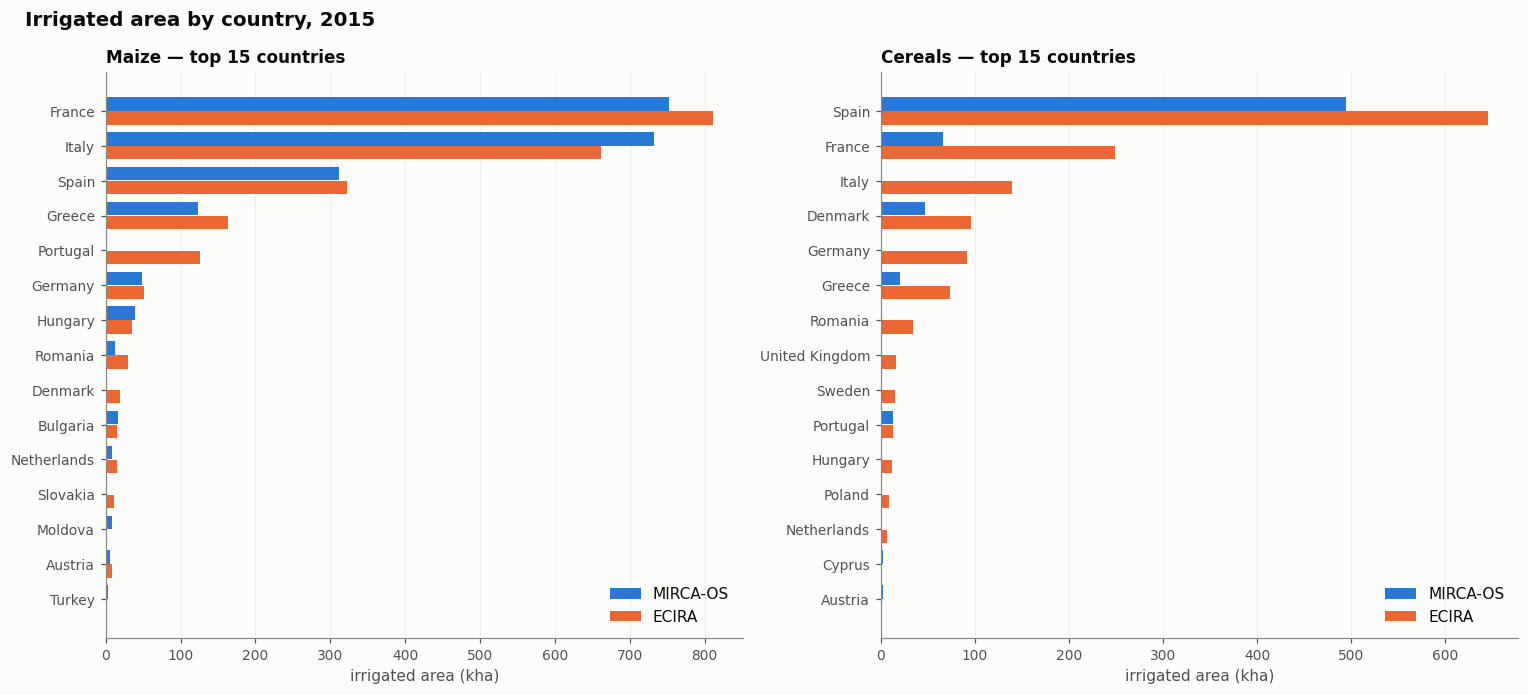

In [22]:
TOP_N = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6.4), sharey=False)

for ax, crop_lbl in zip(axes, ["Maize", "Cereals"]):
    # Rank on the larger of the two products, so a country only one of them sees
    # (ECIRA's Romanian cereals, say) is not ranked off the chart.
    rank = by_country[[f"MIRCA {crop_lbl}", f"ECIRA {crop_lbl}"]].max(axis=1)
    sub = by_country.loc[rank.sort_values(ascending=False).head(TOP_N).index].iloc[::-1]
    y = np.arange(len(sub))
    h = 0.38
    ax.barh(y + h / 2 + 0.01, sub[f"MIRCA {crop_lbl}"], height=h,
            color=C_MIRCA, label="MIRCA-OS")
    ax.barh(y - h / 2 - 0.01, sub[f"ECIRA {crop_lbl}"], height=h,
            color=C_ECIRA, label="ECIRA")
    ax.set_yticks(y, sub.index)
    ax.set_xlabel("irrigated area (kha)")
    ax.set_title(f"{crop_lbl} — top {TOP_N} countries", loc="left")
    ax.grid(True, axis="x", alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right")

fig.suptitle(f"Irrigated area by country, {YEAR}", x=0.02, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(OUT_DIR / "by_country.png", bbox_inches="tight", dpi=150)
plt.show()

In [23]:
# Which countries drive the overall gap.
gap = pd.DataFrame({
    "MIRCA maize (kha)": by_country["MIRCA Maize"],
    "ECIRA maize (kha)": by_country["ECIRA Maize"],
    "maize diff (kha)": by_country["ECIRA Maize"] - by_country["MIRCA Maize"],
    "MIRCA cereals (kha)": by_country["MIRCA Cereals"],
    "ECIRA cereals (kha)": by_country["ECIRA Cereals"],
    "cereals diff (kha)": by_country["ECIRA Cereals"] - by_country["MIRCA Cereals"],
})
gap["abs total diff"] = gap["maize diff (kha)"].abs() + gap["cereals diff (kha)"].abs()
gap.sort_values("abs total diff", ascending=False).head(12).drop(
    columns="abs total diff").round(1)

,MIRCA maize (kha),ECIRA maize (kha),maize diff (kha),MIRCA cereals (kha),ECIRA cereals (kha),cereals diff (kha)
country,,,,,,
France,753.0,810.7,57.7,65.7,249.0,183.3
Italy,732.2,661.9,-70.3,0.0,139.2,139.2
Spain,311.4,322.9,11.5,494.6,645.1,150.5
Portugal,0.4,126.3,125.9,12.7,12.6,-0.1
Greece,122.7,163.9,41.2,20.2,73.2,52.9
Germany,48.8,50.5,1.7,0.2,92.1,91.9
Denmark,0.0,18.5,18.5,46.7,96.2,49.5
Romania,13.0,29.5,16.5,0.7,34.4,33.7
United Kingdom,0.2,0.3,0.2,0.0,16.7,16.7


### Whole-country blanks

The sharpest disagreements are not gradual: for some countries one product reports
a meaningful area and the other reports **essentially none**. That is a crop
*attribution* difference — the irrigation is in both datasets, but assigned to a
different crop class — and it matters far more for a crop model than a 20 % bias,
because a cell with zero area gets no schedule at all.

In [24]:
BLANK_KHA, MATERIAL_KHA = 1.0, 10.0   # "essentially none" vs "worth explaining"

blanks = []
for crop_lbl in ("Maize", "Cereals"):
    m, e = by_country[f"MIRCA {crop_lbl}"], by_country[f"ECIRA {crop_lbl}"]
    for country in by_country.index:
        if m[country] < BLANK_KHA <= MATERIAL_KHA <= e[country]:
            blanks.append({"crop": crop_lbl, "country": country,
                           "MIRCA-OS (kha)": m[country], "ECIRA (kha)": e[country],
                           "blank in": "MIRCA-OS"})
        elif e[country] < BLANK_KHA <= MATERIAL_KHA <= m[country]:
            blanks.append({"crop": crop_lbl, "country": country,
                           "MIRCA-OS (kha)": m[country], "ECIRA (kha)": e[country],
                           "blank in": "ECIRA"})

blanks = pd.DataFrame(blanks)
if blanks.empty:
    print("No country where one product is blank and the other reports > "
          f"{MATERIAL_KHA:.0f} kha.")
else:
    blanks = blanks.sort_values(["crop", "ECIRA (kha)"], ascending=[True, False])
    print(f"Countries where one product reports < {BLANK_KHA:.0f} kha and the other "
          f">= {MATERIAL_KHA:.0f} kha:\n")
    blanks.to_csv(OUT_DIR / "whole_country_blanks.csv", index=False)
display(blanks.set_index(["crop", "country"]).round(1))

Countries where one product reports < 1 kha and the other >= 10 kha:



MIRCA-OS (kha)  ECIRA (kha)  blank in
crop    country                                              
Cereals Italy                      0.0        139.2  MIRCA-OS
        Germany                    0.2         92.1  MIRCA-OS
        Romania                    0.7         34.4  MIRCA-OS
        United Kingdom             0.0         16.7  MIRCA-OS
        Sweden                     0.0         15.6  MIRCA-OS
        Hungary                    0.2         12.0  MIRCA-OS
Maize   Portugal                   0.4        126.3  MIRCA-OS
        Denmark                    0.0         18.5  MIRCA-OS
        Slovakia                   0.0         11.2  MIRCA-OS

## 9 — Why is MIRCA-OS blank there?

A zero in an *irrigated* layer has two very different causes, and they are told
apart by looking one step upstream:

1. **The crop is grown, but MIRCA-OS calls it rainfed.** The rainfed layer for the
   same crop is large and the irrigated one is zero. The zero is then a statement
   about irrigation, inherited from MIRCA-OS's subnational input statistics.
2. **The gridding lost it.** MIRCA-OS's own input — the crop calendar under
   `Crop Calendar/MIRCA-OS_2015_ir.csv`, the subnational irrigated harvested-area
   table the grids are built from — reports area that never reaches the raster.

Both are checked below: first the rainfed companion layers, then the crop calendar.

In [25]:
# Same pipeline, rainfed system.
mirca_rf = {}
for crop, stems in MIRCA_CROPS.items():
    print(f"MIRCA-OS {crop} rainfed ({len(stems)} file(s))")
    mirca_rf[crop] = mirca_annual(mirca_files(stems, "rf"))

for crop in PAIRS:
    ds[f"mirca_{crop}_rainfed"] = (("lat", "lon"),
                                   to_footprint(mirca_rf[crop]["physical"]))
    ds[f"mirca_{crop}_rainfed_full"] = (("lat", "lon"), mirca_rf[crop]["physical"])
    ds[f"mirca_{crop}_rainfed"].attrs = {
        "units": "ha", "definition": "max monthly growing area, rainfed system",
        "masked_to": "ECIRA footprint"}
    ds[f"mirca_{crop}_rainfed_full"].attrs = {
        "units": "ha", "definition": "rainfed, unmasked"}

MIRCA-OS maize rainfed (1 file(s))


  OK physical : source  14,390.5 kha -> target  14,390.5 kha  (+0.000% at the domain edge)


  OK harvested: source  14,390.5 kha -> target  14,390.5 kha  (+0.000% at the domain edge)
MIRCA-OS wheat rainfed (2 file(s))


  OK physical : source  57,387.6 kha -> target  57,387.6 kha  (+0.000% at the domain edge)


  OK harvested: source  57,387.6 kha -> target  57,387.6 kha  (+0.000% at the domain edge)
MIRCA-OS cereals rainfed (6 file(s))


  OK physical : source  86,319.6 kha -> target  86,319.6 kha  (+0.000% at the domain edge)


  OK harvested: source  86,481.2 kha -> target  86,481.2 kha  (+0.000% at the domain edge)


In [26]:
# The *_full (unmasked) fields are deliberate here: the question is what MIRCA-OS
# itself says about a country, which the ECIRA footprint must not be allowed to
# clip. Every other section uses the masked one-to-one fields.
rows = []
for cid, name in enumerate(COUNTRY_NAMES, start=1):
    sel = country_grid == cid
    if not sel.any():
        continue
    row = {"country": name}
    for crop in ("maize", "cereals"):
        lbl = PAIRS[crop][0]
        i = ds[f"mirca_{crop}_full"].values[sel].sum() / 1e3
        r = ds[f"mirca_{crop}_rainfed_full"].values[sel].sum() / 1e3
        row[f"{lbl} ir"] = i
        row[f"{lbl} rf"] = r
        row[f"{lbl} ir share %"] = 100 * i / max(i + r, 1e-9)
        row[f"{lbl} ECIRA ir"] = ds[f"ecira_{crop}"].values[sel].sum() / 1e3
    rows.append(row)

systems = pd.DataFrame(rows).set_index("country")
systems = systems.loc[(systems[["Maize ir", "Maize rf", "Cereals ir", "Cereals rf"]]
                       .sum(axis=1) > 50)]
focus = [c for c in ["Italy", "Germany", "Romania", "United Kingdom", "Sweden",
                     "Hungary", "Poland", "Portugal", "Spain", "France", "Denmark",
                     "Greece"] if c in systems.index]
systems.loc[focus].round(1)

,Maize ir,Maize rf,Maize ir share %,Maize ECIRA ir,Cereals ir,Cereals rf,Cereals ir share %,Cereals ECIRA ir
country,,,,,,,,
Italy,732.5,114.8,86.4,661.9,0.0,1704.9,0.0,139.2
Germany,48.8,389.1,11.1,50.5,0.2,5000.2,0.0,92.1
Romania,13.0,2051.8,0.6,29.5,0.7,1809.2,0.0,34.4
United Kingdom,0.2,0.0,100.0,0.3,0.0,1911.6,0.0,16.7
Sweden,1.3,0.3,78.7,1.1,0.0,777.0,0.0,15.6
Hungary,39.7,650.5,5.7,35.5,0.2,852.2,0.0,12.0
Poland,0.8,571.8,0.1,2.6,0.2,3124.5,0.0,8.8
Portugal,0.4,63.3,0.6,126.3,12.7,21.2,37.5,12.6
Spain,311.7,76.0,80.4,322.9,494.7,3475.2,12.5,645.1


In [27]:
# Read MIRCA-OS's own input statistics and compare them with the gridded product.
CALENDAR = (MIRCA_DIR.parents[2] / "Crop Calendar" / f"MIRCA-OS_{YEAR}_ir.csv")

# The calendar uses UN-style country names; Natural Earth uses short ones.
CAL_TO_NE = {
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Netherlands (Kingdom of the)": "Netherlands",
    "Republic of Moldova": "Moldova",
    "North Macedonia": "Macedonia",
    "Serbia": "Republic of Serbia",
    "Czechia": "Czech Republic",
    "Russian Federation": "Russia",
    "Türkiye": "Turkey",
    "Syrian Arab Republic": "Syria",
}
CAL_CROPS = {"cereals": ["Wheat1", "Wheat2", "Barley", "Rye", "Millet", "Sorghum"],
             "maize": ["Maize"]}

cal = pd.read_csv(CALENDAR, encoding="latin-1")
cal["country"] = cal["Country"].replace(CAL_TO_NE)

rows = []
for crop, crop_names in CAL_CROPS.items():
    lbl = PAIRS[crop][0]
    stat = (cal[cal["Crop"].isin(crop_names)]
            .groupby("country")["Growing_area"].sum() / 1e3)
    for country in focus:
        if country not in systems.index:
            continue
        gridded = systems.loc[country, f"{lbl} ir"]
        reported = float(stat.get(country, np.nan))
        rows.append({
            "crop": lbl, "country": country,
            "crop calendar (kha)": reported,
            "gridded (kha)": gridded,
            "gridded / calendar": gridded / reported if reported > 0 else np.nan,
            "ECIRA (kha)": systems.loc[country, f"{lbl} ECIRA ir"],
        })

calendar_check = pd.DataFrame(rows).set_index(["crop", "country"])
calendar_check.to_csv(OUT_DIR / "mirca_calendar_vs_grid.csv")
calendar_check.round(2)

crop calendar (kha)  gridded (kha)  gridded / calendar  ECIRA (kha)
crop    country                                                                            
Cereals Italy                        118.00           0.00                0.00       139.23
        Germany                        0.00           0.15                 NaN        92.06
        Romania                        0.00           0.69                 NaN        34.42
        United Kingdom                 0.00           0.00                 NaN        16.70
        Sweden                         0.00           0.02                 NaN        15.55
        Hungary                        0.00           0.20                 NaN        11.96
        Poland                         0.00           0.18                 NaN         8.83
        Portugal                      13.55          12.74                0.94        12.63
        Spain                        579.20         494.69                0.85       645.11
        France                        89.82          65.73                0.73       249.04
        Denmark                       75.10          46.70                0.62        96.22
        Greece                        31.00          20.28                0.65        73.15
Maize   Italy                        736.00         732.49                1.00       661.87
        Germany                       48.93          48.79                1.00        50.53
        Romania                       28.35          13.03                0.46        29.49
        United Kingdom                 0.18           0.17                0.96         0.34
        Sweden                         1.37           1.29                0.94         1.14
        Hungary                       38.33          39.66                1.03        35.53
        Poland                         0.73           0.82                1.13         2.56
        Portugal                       0.00           0.37                 NaN       126.31
        Spain                        313.84         311.73                0.99       322.92
        France                       756.00         753.07                1.00       810.71
        Denmark                        0.00           0.03                 NaN        18.50
        Greece                       133.71         124.81                0.93       163.95

In [28]:
print("Diagnosis of every country MIRCA-OS leaves blank\n")
for (lbl, country), r in calendar_check.iterrows():
    if r["gridded (kha)"] >= 1.0 or r["ECIRA (kha)"] < 10.0:
        continue
    rf = systems.loc[country, f"{lbl} rf"]
    if r["crop calendar (kha)"] > 1.0:
        cause = (f"GRIDDING LOSS - the calendar reports "
                 f"{r['crop calendar (kha)']:,.0f} kha of irrigated {lbl.lower()}, "
                 f"the raster has {r['gridded (kha)']:.2f} kha")
    else:
        cause = (f"INPUT STATISTICS - the calendar itself reports "
                 f"{r['crop calendar (kha)']:,.0f} kha irrigated; MIRCA-OS puts all "
                 f"{rf:,.0f} kha of this crop in the rainfed layer")
    print(f"  {country} / {lbl}: {cause}")
    print(f"      ECIRA sees {r['ECIRA (kha)']:,.0f} kha irrigated here\n")

Diagnosis of every country MIRCA-OS leaves blank

  Italy / Cereals: GRIDDING LOSS - the calendar reports 118 kha of irrigated cereals, the raster has 0.00 kha
      ECIRA sees 139 kha irrigated here

  Germany / Cereals: INPUT STATISTICS - the calendar itself reports 0 kha irrigated; MIRCA-OS puts all 5,000 kha of this crop in the rainfed layer
      ECIRA sees 92 kha irrigated here

  Romania / Cereals: INPUT STATISTICS - the calendar itself reports 0 kha irrigated; MIRCA-OS puts all 1,809 kha of this crop in the rainfed layer
      ECIRA sees 34 kha irrigated here

  United Kingdom / Cereals: INPUT STATISTICS - the calendar itself reports 0 kha irrigated; MIRCA-OS puts all 1,912 kha of this crop in the rainfed layer
      ECIRA sees 17 kha irrigated here

  Sweden / Cereals: INPUT STATISTICS - the calendar itself reports 0 kha irrigated; MIRCA-OS puts all 777 kha of this crop in the rainfed layer
      ECIRA sees 16 kha irrigated here

  Hungary / Cereals: INPUT STATISTICS - the cal

Read `gridded / calendar` for its **zeros**, not its exact value. A ratio near 1
(most of the maize column) confirms the whole chain — half-cell fix, conservative
remap, country mask — reproduces MIRCA-OS's own input statistics. Ratios of
0.6–0.9 mostly reflect the country mask: a 0.1° cell is assigned to the country
containing its *centre*, so coastal and border cells leak, which bites hardest for
Denmark and Greece. Only a ratio at zero, with a non-zero calendar entry, means
the grid genuinely lost the area.

Neither cause is a defect of the regridding in this notebook — both are properties
of MIRCA-OS v0.1 — but they call for different handling:

- **Input-statistics zeros** are a coverage judgement. MIRCA-OS's subnational
  tables record no irrigated cereals in Germany, Romania, the UK, Sweden, Hungary
  or Poland, and no irrigated maize in Portugal, so the grids cannot show any. The
  underlying areas are all present in the *rainfed* layers. Where ECIRA reports
  irrigation there, the two disagree about the irrigation status of real cropland,
  not about where the crop is.
- **Gridding losses** are an internal inconsistency: the area is in MIRCA-OS's own
  input and missing from its output. Treat those countries as unreported rather
  than as zero.

For a SIMPLACE run, an irrigated-area mask taken from MIRCA-OS alone will therefore
declare whole countries rainfed. ECIRA is the better mask inside its EU/EEA
footprint; MIRCA-OS is the only option outside it.

## 10 — Binary irrigation classification (`vIRR`)

Each 0.1° cell is labelled **1 = irrigated** / **0 = rainfed** from the share of the
crop's harvested area that is irrigated:

$$f = \frac{A_{\text{irrigated}}}{A_{\text{irrigated}} + A_{\text{rainfed}}}
\qquad v_{\text{IRR}} = \begin{cases} 1 & f > 0.5 \\ 0 & \text{otherwise}\end{cases}$$

Three decisions this needs, all explicit below:

- **Which area.** MIRCA-OS's `harvested` definition is used for both numerator and
  denominator — it is literally the harvested area the rule refers to, and the ir
  and rf peaks need not fall in the same month, so the `physical` maxima would not
  add up to a meaningful total. ECIRA has one season, so its `Crop_A` (= IR + RF,
  per its README) is both.
- **A minimum area.** A cell holding 0.2 ha of the crop would otherwise get a
  confident label off a rounding difference. `VIRR_MIN_AREA_HA` leaves such cells
  **unclassified (−1)** rather than forcing them to 0.
- **Which product.** The two disagree (§9), so `vIRR` is produced for each
  separately, plus a merged layer that follows §9's conclusion: ECIRA inside its
  footprint, MIRCA-OS outside it.

A binary label moves area around — a cell at f = 0.55 is counted fully irrigated,
one at f = 0.45 fully rainfed. The table below reports that reallocation so the
cost of thresholding is visible rather than assumed small.

In [29]:
VIRR_THRESHOLD = 0.5     # f > this -> irrigated
VIRR_MIN_AREA_HA = 10.0  # a cell needs this much of the crop to be classified at all
VIRR_UNDEFINED = -1

# ECIRA growing area (Crop_A = Crop_IR + Crop_RF) is the denominator on its side.
ECIRA_TOTAL_CROPS = {"maize": "LMAIZ_A_2015.tif", "cereals": "CERE_A_2015.tif"}
ecira_total = {}
for crop, fname in ECIRA_TOTAL_CROPS.items():
    print(f"ECIRA {crop} growing area")
    ecira_total[crop] = regridder.regrid(ECIRA_A_DIR / fname, label=f"{crop:9s}")
ecira_total["wheat"] = ecira_total["cereals"]


def irrigated_fraction(irrigated: np.ndarray, total: np.ndarray) -> np.ndarray:
    """Share of a cell's crop area that is irrigated; NaN where there is too little crop."""
    frac = np.divide(irrigated, total, out=np.full(total.shape, np.nan),
                     where=total > 0)
    return np.where(total >= VIRR_MIN_AREA_HA, frac, np.nan)


def classify_virr(frac: np.ndarray) -> np.ndarray:
    """1 = irrigated, 0 = rainfed, -1 = too little of the crop to classify."""
    return np.where(np.isnan(frac), VIRR_UNDEFINED,
                    (frac > VIRR_THRESHOLD).astype(np.int8)).astype(np.int8)


for crop in PAIRS:
    # Unmasked MIRCA-OS on purpose: the class is a statement about a cell, not a
    # comparison, and the merged layer below needs a label outside ECIRA's reach.
    # The MIRCA-vs-ECIRA agreement table further down still restricts to `coverage`.
    m_ir = mirca[crop]["harvested"]
    m_tot = m_ir + mirca_rf[crop]["harvested"]
    m_frac = irrigated_fraction(m_ir, m_tot)

    # ECIRA: irrigated over growing area.
    e_frac = irrigated_fraction(ds[f"ecira_{crop}"].values, ecira_total[crop])

    ds[f"mirca_{crop}_total"] = (("lat", "lon"), m_tot)
    ds[f"ecira_{crop}_total"] = (("lat", "lon"), ecira_total[crop])
    ds[f"mirca_{crop}_irr_fraction"] = (("lat", "lon"), m_frac.astype("float32"))
    ds[f"ecira_{crop}_irr_fraction"] = (("lat", "lon"), e_frac.astype("float32"))
    ds[f"mirca_{crop}_vIRR"] = (("lat", "lon"), classify_virr(m_frac))
    ds[f"ecira_{crop}_vIRR"] = (("lat", "lon"), classify_virr(e_frac))

    for prod in ("mirca", "ecira"):
        ds[f"{prod}_{crop}_vIRR"].attrs = {
            "long_name": f"binary irrigation class for {crop} from {prod.upper()}",
            "flag_values": "-1 0 1",
            "flag_meanings": "unclassified rainfed irrigated",
            "rule": f"1 where irrigated/(irrigated+rainfed) > {VIRR_THRESHOLD}",
            "min_crop_area_ha": VIRR_MIN_AREA_HA,
        }

print(f"\nrule: vIRR = 1 where f > {VIRR_THRESHOLD}, "
      f"cells with < {VIRR_MIN_AREA_HA:.0f} ha of the crop left unclassified")

ECIRA maize growing area


  OK maize    : source  15,933.1 kha -> target  15,933.1 kha  (+0.000% at the domain edge)
ECIRA cereals growing area


  OK cereals  : source  46,231.1 kha -> target  46,231.1 kha  (+0.000% at the domain edge)

rule: vIRR = 1 where f > 0.5, cells with < 10 ha of the crop left unclassified


In [30]:
rows = []
for crop in PAIRS:
    for prod, lbl in (("mirca", "MIRCA-OS"), ("ecira", "ECIRA")):
        virr = ds[f"{prod}_{crop}_vIRR"].values
        tot = ds[f"{prod}_{crop}_total"].values
        ir = ds[f"{prod}_{crop}"].values if prod == "ecira" else mirca[crop]["harvested"]
        known = virr >= 0
        rows.append({
            "crop": PAIRS[crop][0], "product": lbl,
            "cells with the crop": int(known.sum()),
            "vIRR = 1": int((virr == 1).sum()),
            "% of cells irrigated": 100 * (virr == 1).sum() / max(known.sum(), 1),
            "true irrigated (kha)": ir[known].sum() / 1e3,
            "area in vIRR=1 cells (kha)": tot[virr == 1].sum() / 1e3,
        })

virr_summary = pd.DataFrame(rows).set_index(["crop", "product"])
virr_summary["thresholding bias (%)"] = (
    100 * (virr_summary["area in vIRR=1 cells (kha)"]
           / virr_summary["true irrigated (kha)"] - 1))
virr_summary.round(1)

cells with the crop  vIRR = 1  % of cells irrigated  true irrigated (kha)  area in vIRR=1 cells (kha)  thresholding bias (%)
crop    product                                                                                                                               
Maize   MIRCA-OS                61402     15176                  24.7                2984.4                      2864.8                   -4.0
        ECIRA                   37427      3022                   8.1                2289.1                      2057.3                  -10.1
Wheat   MIRCA-OS                96085      2605                   2.7                2079.3                      1845.3                  -11.3
        ECIRA                   48614       374                   0.8                1415.8                       589.8                  -58.3
Cereals MIRCA-OS               102000      2272                   2.2                3079.0                      2317.1                  -24.7
        ECIRA                   48614       374                   0.8                1415.8                       589.8                  -58.3

`thresholding bias` is what the binary label costs: the crop area sitting in cells
called irrigated, against the area actually irrigated. A large positive value means
the label promotes partly-irrigated cells to fully irrigated; a large negative one
means most irrigation lives in cells that are majority-rainfed and the label
discards it.

In [31]:
# Do the two products agree on the label, where both classify the cell?
conf_rows = []
for crop in PAIRS:
    m, e = ds[f"mirca_{crop}_vIRR"].values, ds[f"ecira_{crop}_vIRR"].values
    both = (m >= 0) & (e >= 0) & coverage
    n = int(both.sum())
    if n == 0:
        continue
    n11 = int(((m == 1) & (e == 1) & both).sum())
    n00 = int(((m == 0) & (e == 0) & both).sum())
    n10 = int(((m == 1) & (e == 0) & both).sum())
    n01 = int(((m == 0) & (e == 1) & both).sum())
    po = (n11 + n00) / n
    pe = ((n11 + n10) * (n11 + n01) + (n00 + n01) * (n00 + n10)) / n**2
    conf_rows.append({
        "crop": PAIRS[crop][0], "cells both classify": n,
        "both irrigated": n11, "both rainfed": n00,
        "MIRCA irr / ECIRA rf": n10, "MIRCA rf / ECIRA irr": n01,
        "agreement %": 100 * po,
        "Cohen kappa": (po - pe) / (1 - pe) if pe < 1 else np.nan,
    })

virr_agreement = pd.DataFrame(conf_rows).set_index("crop")
virr_agreement.round(2)

,cells both classify,both irrigated,both rainfed,MIRCA irr / ECIRA rf,MIRCA rf / ECIRA irr,agreement %,Cohen kappa
crop,,,,,,,
Maize,26781,2529,18800,5105,347,79.64,0.39
Wheat,40290,158,39149,778,205,97.56,0.23
Cereals,42317,165,41360,592,200,98.13,0.29


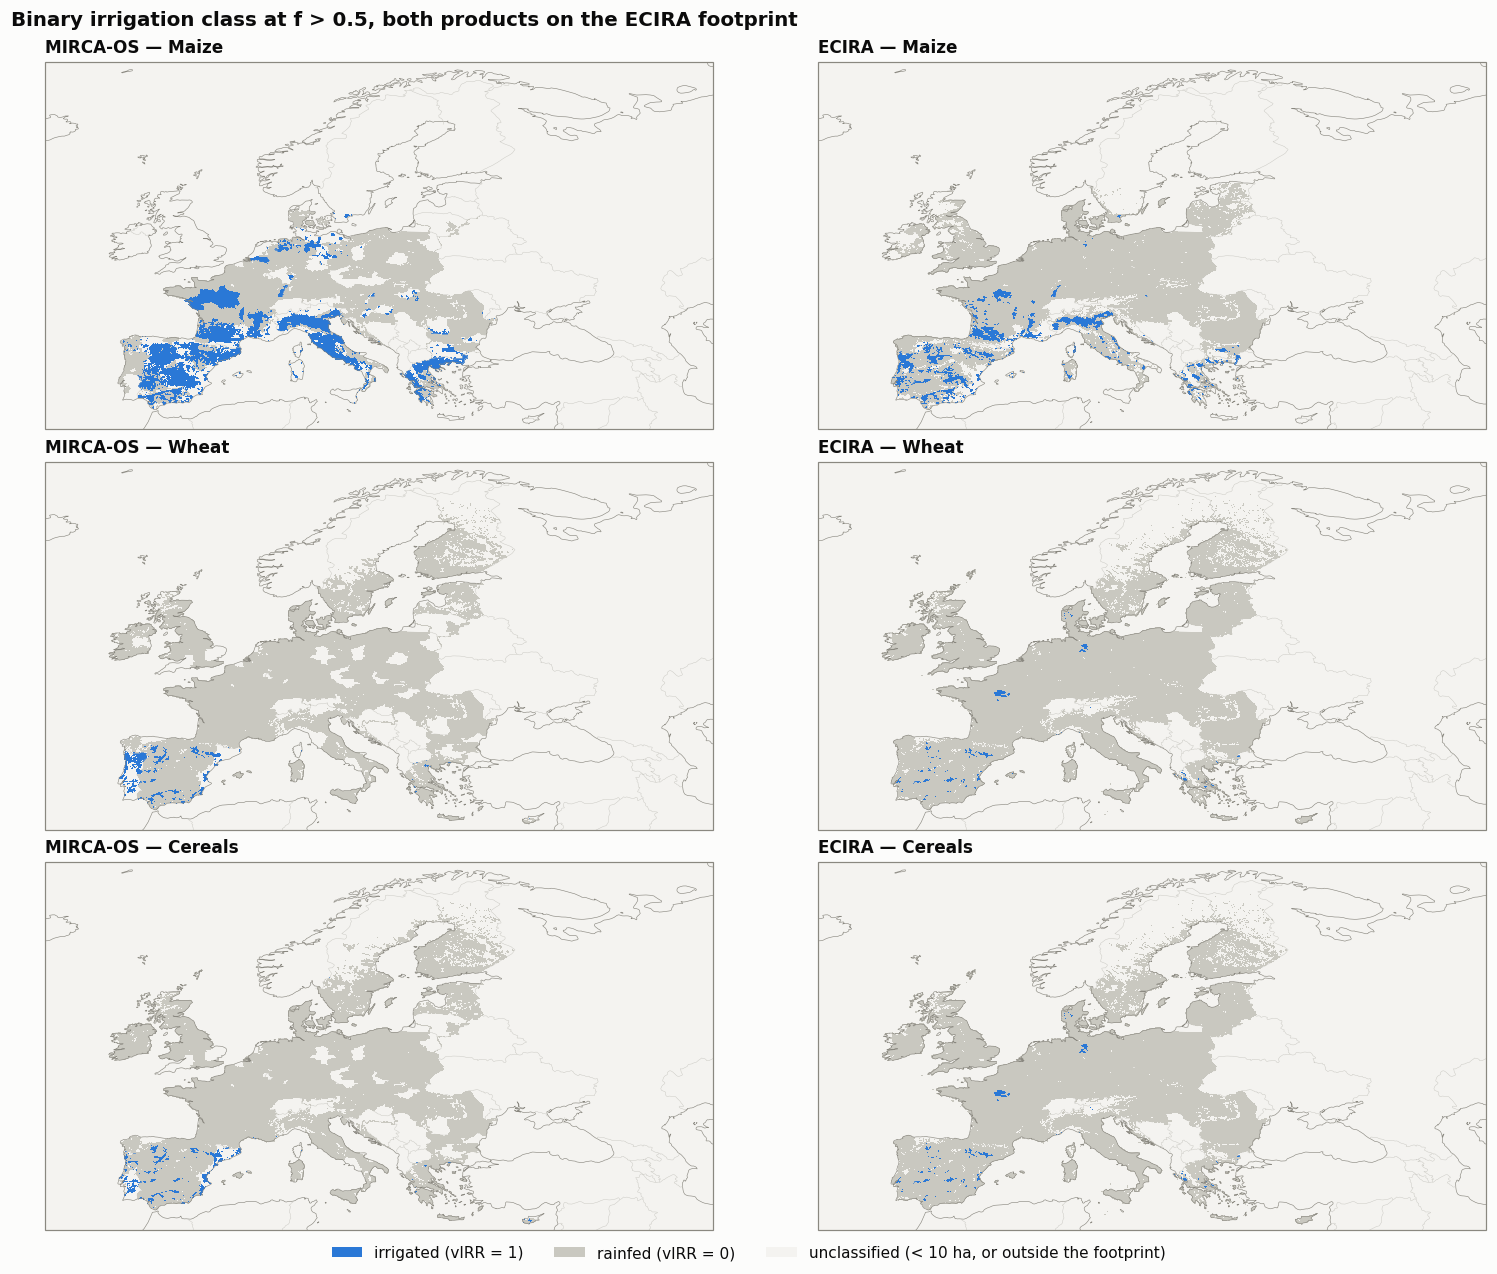

In [32]:
# Irrigated is the signal, so it takes the saturated hue; rainfed is the baseline
# class and stays recessive, and unclassified recedes to near the surface.
C_IRR, C_RF, C_NONE = C_MIRCA, "#c9c8c0", "#f4f3f0"
virr_cmap = ListedColormap([C_NONE, C_RF, C_IRR])
virr_norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3)

fig, axes = plt.subplots(3, 2, figsize=(14, 11.5), layout="constrained",
                         subplot_kw={"projection": proj})

for row, crop in enumerate(PAIRS):
    for col, (prod, lbl) in enumerate((("mirca", "MIRCA-OS"), ("ecira", "ECIRA"))):
        ax = axes[row, col]
        # This figure is a comparison, so both columns are clipped to the ECIRA
        # footprint like §4 - otherwise the MIRCA column would carry Turkey,
        # Ukraine and North Africa against an ECIRA column that stops at the EU
        # border, and the extra extent would read as a disagreement.
        virr = np.where(coverage, ds[f"{prod}_{crop}_vIRR"].values, VIRR_UNDEFINED)
        ax.pcolormesh(LON_EDGES, LAT_EDGES, virr.astype(float),
                      cmap=virr_cmap, norm=virr_norm, transform=proj, shading="flat")
        add_map_frame(ax)
        ax.set_title(f"{lbl} — {PAIRS[crop][0]}", loc="left")

handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in
           ((C_IRR, "irrigated (vIRR = 1)"), (C_RF, "rainfed (vIRR = 0)"),
            (C_NONE, f"unclassified (< {VIRR_MIN_AREA_HA:.0f} ha, or outside the footprint)"))]
fig.legend(handles=handles, loc="outside lower center", ncol=3)
fig.suptitle(f"Binary irrigation class at f > {VIRR_THRESHOLD}, "
             "both products on the ECIRA footprint",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.savefig(OUT_DIR / "virr_classification.png", bbox_inches="tight", dpi=150)
plt.show()

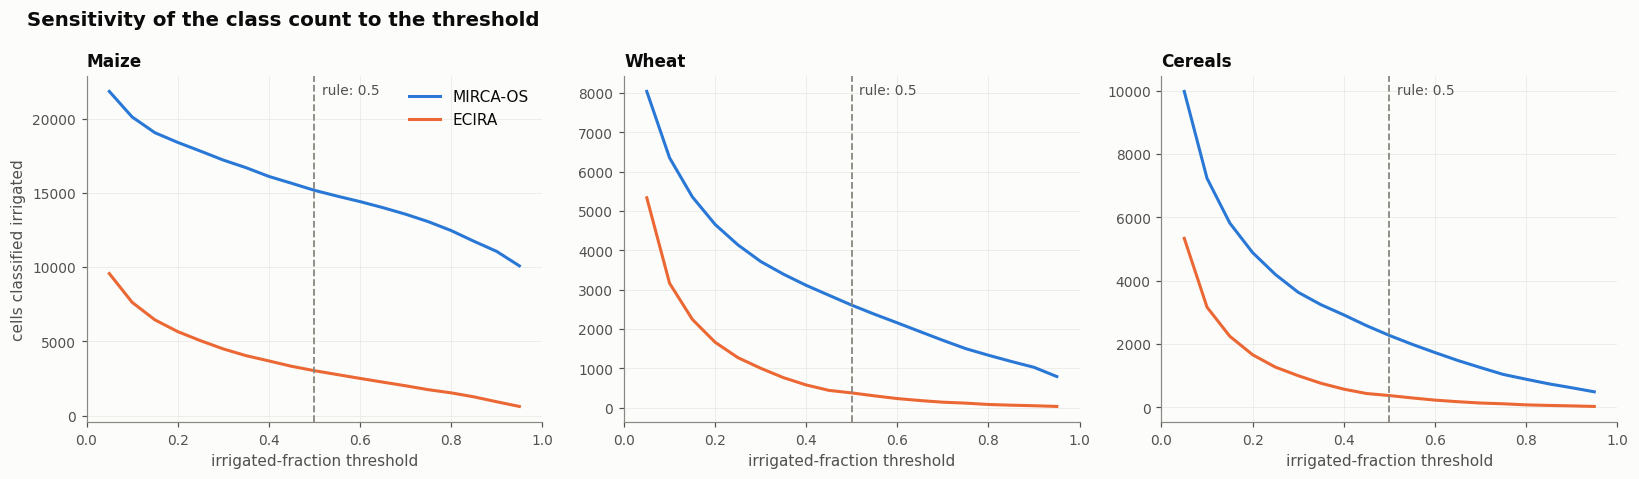

In [33]:
# How much does the answer hinge on 0.5?
THRESHOLDS = np.arange(0.05, 1.0, 0.05)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=False)

for ax, crop in zip(axes, PAIRS):
    for prod, lbl, colour in (("mirca", "MIRCA-OS", C_MIRCA), ("ecira", "ECIRA", C_ECIRA)):
        frac = ds[f"{prod}_{crop}_irr_fraction"].values
        known = np.isfinite(frac)
        counts = [(frac[known] > t).sum() for t in THRESHOLDS]
        ax.plot(THRESHOLDS, counts, color=colour, label=lbl)
    ax.axvline(VIRR_THRESHOLD, color=INK_3, lw=1.2, ls="--")
    ax.annotate(f"rule: {VIRR_THRESHOLD}", (VIRR_THRESHOLD, ax.get_ylim()[1]),
                textcoords="offset points", xytext=(5, -12), color=INK_2, fontsize=9)
    ax.set(xlabel="irrigated-fraction threshold", xlim=(0, 1))
    ax.set_title(PAIRS[crop][0], loc="left")
    ax.grid(True, alpha=0.7)
axes[0].set_ylabel("cells classified irrigated")
axes[0].legend(loc="upper right")

fig.suptitle("Sensitivity of the class count to the threshold", x=0.02, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(OUT_DIR / "virr_threshold_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

In [34]:
# Merged layer: ECIRA where it classifies inside its footprint, else MIRCA-OS.
# §9 is the justification - MIRCA-OS reports whole countries as fully rainfed.
SOURCE_NONE, SOURCE_ECIRA, SOURCE_MIRCA = 0, 1, 2

for crop in PAIRS:
    m, e = ds[f"mirca_{crop}_vIRR"].values, ds[f"ecira_{crop}_vIRR"].values
    use_e = (e >= 0) & coverage
    merged = np.where(use_e, e, m).astype(np.int8)
    source = np.where(use_e, SOURCE_ECIRA,
                      np.where(m >= 0, SOURCE_MIRCA, SOURCE_NONE)).astype(np.int8)
    ds[f"vIRR_{crop}"] = (("lat", "lon"), merged)
    ds[f"vIRR_{crop}_source"] = (("lat", "lon"), source)
    ds[f"vIRR_{crop}"].attrs = {
        "long_name": f"merged binary irrigation class for {crop}",
        "flag_values": "-1 0 1", "flag_meanings": "unclassified rainfed irrigated",
        "rule": f"irrigated share > {VIRR_THRESHOLD} of harvested area",
        "priority": "ECIRA inside its footprint, MIRCA-OS elsewhere",
    }
    ds[f"vIRR_{crop}_source"].attrs = {
        "flag_values": "0 1 2", "flag_meanings": "none ECIRA MIRCA-OS"}

merge_rows = []
for crop in PAIRS:
    v, s = ds[f"vIRR_{crop}"].values, ds[f"vIRR_{crop}_source"].values
    merge_rows.append({
        "crop": PAIRS[crop][0],
        "classified cells": int((v >= 0).sum()),
        "irrigated (vIRR=1)": int((v == 1).sum()),
        "rainfed (vIRR=0)": int((v == 0).sum()),
        "from ECIRA": int((s == SOURCE_ECIRA).sum()),
        "from MIRCA-OS": int((s == SOURCE_MIRCA).sum()),
    })
pd.DataFrame(merge_rows).set_index("crop")

,classified cells,irrigated (vIRR=1),rainfed (vIRR=0),from ECIRA,from MIRCA-OS
crop,,,,,
Maize,72048,10564,61484,37427,34621
Wheat,104409,2043,102366,48614,55795
Cereals,108297,1889,106408,48614,59683


38 countries in ECIRA's remit: Akrotiri Sovereign Base Area, Aland, Andorra, Austria, Belgium, Bosnia and Herzegovina, Bulgaria, Croatia, Cyprus, Czech Republic, Denmark, Dhekelia Sovereign Base Area, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Moldova, Netherlands, Northern Cyprus, Poland, Portugal, Republic of Serbia, Romania, San Marino, Slovakia, Slovenia, Spain, Sweden, Switzerland, United Kingdom


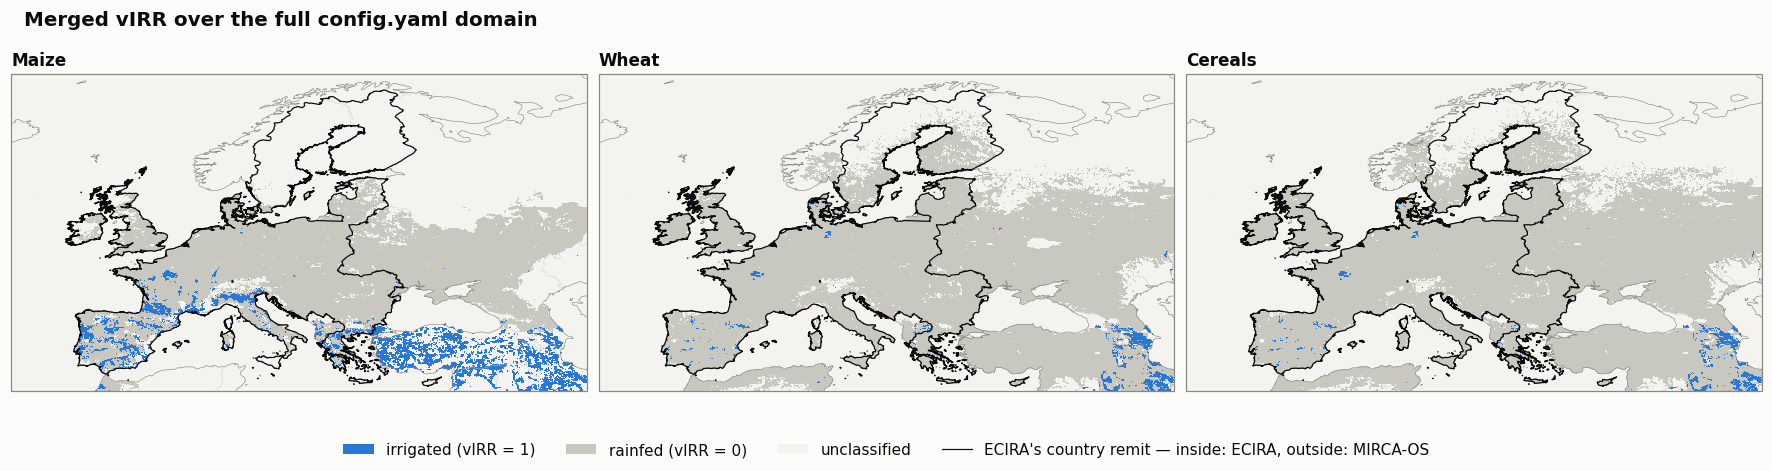

In [35]:
# The merged layer is the deliverable, not a comparison, so here the full domain
# is the point: the outline marks where the source switches from ECIRA to MIRCA-OS.
#
# ECIRA's footprint is a per-cell cropland mask, so contouring it directly draws
# thousands of speckles. Its actual remit is a set of *countries*, so the outline
# is drawn from the national polygons instead - one clean boundary.
ECIRA_COUNTRY_MIN_SHARE = 0.05

ecira_countries = [name for i, name in enumerate(COUNTRY_NAMES, start=1)
                   if (country_grid == i).any()
                   and coverage[country_grid == i].mean() > ECIRA_COUNTRY_MIN_SHARE]
ecira_region = adm[adm["admin"].isin(ecira_countries)].dissolve()
print(f"{len(ecira_countries)} countries in ECIRA's remit: "
      f"{', '.join(sorted(ecira_countries))}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained",
                         subplot_kw={"projection": proj})

for ax, crop in zip(axes, PAIRS):
    ax.pcolormesh(LON_EDGES, LAT_EDGES, ds[f"vIRR_{crop}"].values.astype(float),
                  cmap=virr_cmap, norm=virr_norm, transform=proj, shading="flat")
    ax.add_geometries(ecira_region.geometry, crs=proj, facecolor="none",
                      edgecolor=INK_1, linewidth=0.8, zorder=3)
    add_map_frame(ax)
    ax.set_title(PAIRS[crop][0], loc="left")

handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in
           ((C_IRR, "irrigated (vIRR = 1)"), (C_RF, "rainfed (vIRR = 0)"),
            (C_NONE, "unclassified"))]
handles.append(mpl.lines.Line2D([], [], color=INK_1, lw=0.8,
                                label="ECIRA's country remit — inside: ECIRA, outside: MIRCA-OS"))
fig.legend(handles=handles, loc="outside lower center", ncol=4)
fig.suptitle("Merged vIRR over the full config.yaml domain",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.savefig(OUT_DIR / "virr_merged.png", bbox_inches="tight", dpi=150)
plt.show()

In [36]:
# Per-cell table for the classified cells, keyed on the grid coordinates the rest
# of the pipeline uses.
lon2d, lat2d = np.meshgrid(LON, LAT)
row, col = np.meshgrid(np.arange(NLAT), np.arange(NLON), indexing="ij")

table = pd.DataFrame({
    "lat": lat2d.ravel(), "lon": lon2d.ravel(),
    "row": row.ravel(), "col": col.ravel(),
})
for crop in PAIRS:
    lbl = PAIRS[crop][0].lower()
    table[f"vIRR_{lbl}"] = ds[f"vIRR_{crop}"].values.ravel()
    table[f"vIRR_{lbl}_source"] = ds[f"vIRR_{crop}_source"].values.ravel()
    table[f"irr_frac_{lbl}_mirca"] = ds[f"mirca_{crop}_irr_fraction"].values.ravel()
    table[f"irr_frac_{lbl}_ecira"] = ds[f"ecira_{crop}_irr_fraction"].values.ravel()

keep = (table[[f"vIRR_{PAIRS[c][0].lower()}" for c in PAIRS]] >= 0).any(axis=1)
table = table[keep].round(4)
table.to_csv(OUT_DIR / f"vIRR_{YEAR}_{RES}deg.csv", index=False)
print(f"{len(table):,} classified cells -> vIRR_{YEAR}_{RES}deg.csv")
table.head(10)

108,779 classified cells -> vIRR_2015_0.1deg.csv


,lat,lon,row,col,vIRR_maize,vIRR_maize_source,irr_frac_maize_mirca,irr_frac_maize_ecira,vIRR_wheat,vIRR_wheat_source,irr_frac_wheat_mirca,irr_frac_wheat_ecira,vIRR_cereals,vIRR_cereals_source,irr_frac_cereals_mirca,irr_frac_cereals_ecira
101,34.05,-6.85,0,101,1,2,0.9673,NaN,0,2,0.0,NaN,0,2,0.2386,NaN
102,34.05,-6.75,0,102,1,2,0.6103,NaN,0,2,0.0,NaN,0,2,0.0163,NaN
103,34.05,-6.65,0,103,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
104,34.05,-6.55,0,104,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
105,34.05,-6.45,0,105,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
106,34.05,-6.35,0,106,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
107,34.05,-6.25,0,107,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
108,34.05,-6.15,0,108,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
109,34.05,-6.05,0,109,0,2,0.0000,NaN,0,2,0.0,NaN,0,2,0.0000,NaN
110,34.05,-5.95,0,110,0,2,0.0845,NaN,0,2,0.0,NaN,0,2,0.0063,NaN


**Caveats worth carrying forward.** The label inherits every disagreement of §5–§9:
where MIRCA-OS reports a country's cereals as entirely rainfed, its `vIRR` is 0
everywhere in that country regardless of threshold. The merged layer prefers ECIRA
for exactly that reason, but only inside the EU/EEA footprint — outside it the
label rests on MIRCA-OS alone and the country-level zeros of §9 apply unchecked.
The threshold sensitivity plot shows how much the count moves if 0.5 is loosened;
where the curve is steep at 0.5 the label on those cells is not robust.

## 11 — Latitudinal and distributional structure

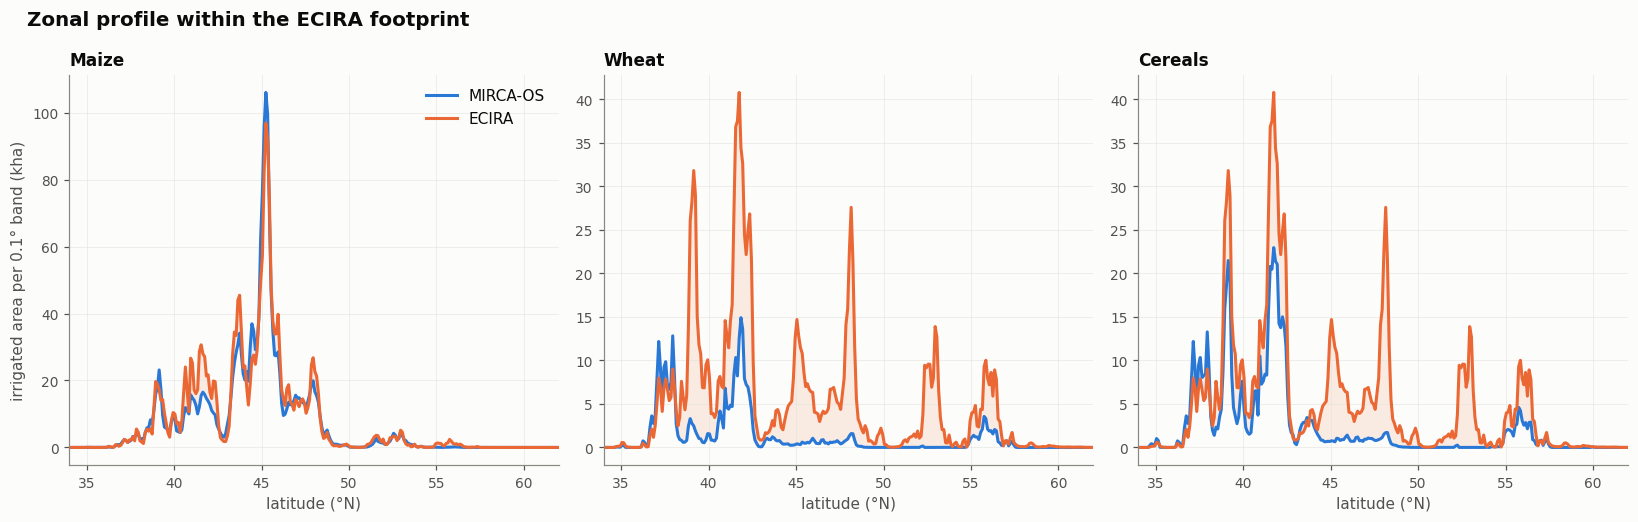

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)

for ax, crop in zip(axes, PAIRS):
    m = np.where(coverage, ds[f"mirca_{crop}"].values, 0.0).sum(axis=1) / 1e3
    e = np.where(coverage, ds[f"ecira_{crop}"].values, 0.0).sum(axis=1) / 1e3
    ax.plot(LAT, m, color=C_MIRCA, label="MIRCA-OS")
    ax.plot(LAT, e, color=C_ECIRA, label="ECIRA")
    ax.fill_between(LAT, m, e, where=e >= m, color=C_ECIRA, alpha=0.12, lw=0)
    ax.fill_between(LAT, m, e, where=e < m, color=C_MIRCA, alpha=0.12, lw=0)
    ax.set(xlabel="latitude (°N)", xlim=(LAT_MIN, 62))
    ax.set_title(PAIRS[crop][0], loc="left")
    ax.grid(True, alpha=0.7)
axes[0].set_ylabel("irrigated area per 0.1° band (kha)")
axes[0].legend(loc="upper right")

fig.suptitle("Zonal profile within the ECIRA footprint", x=0.02, ha="left",
             fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(OUT_DIR / "zonal_profile.png", bbox_inches="tight", dpi=150)
plt.show()

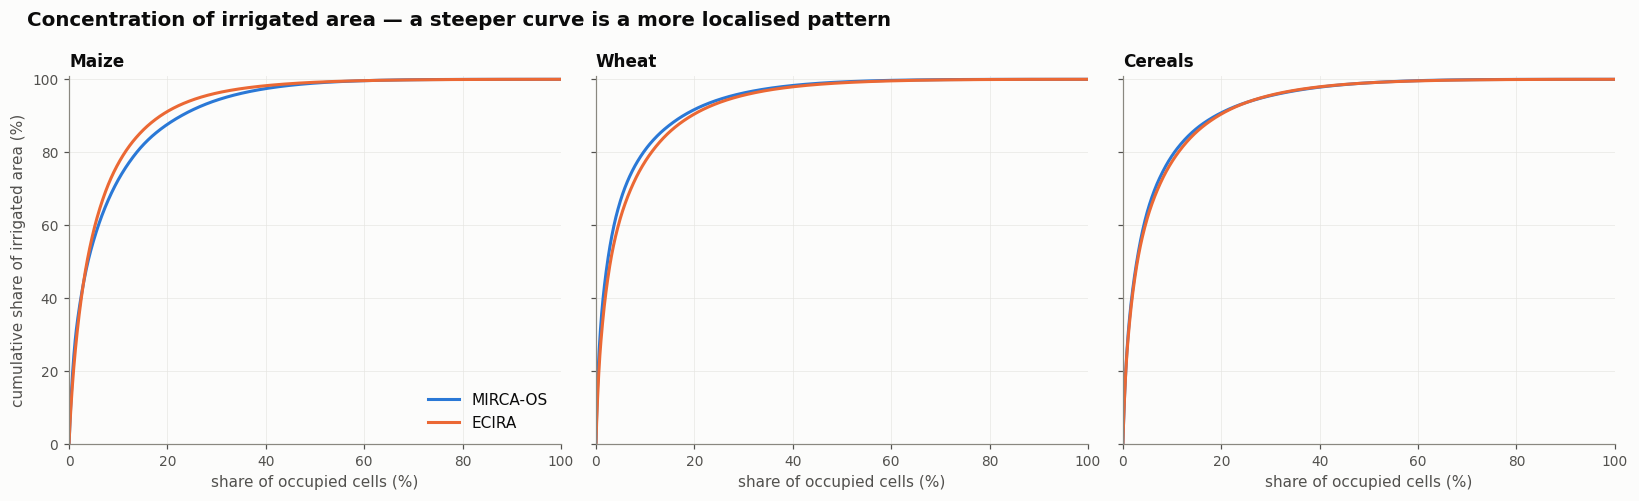

cells with crop  cells holding 50% of area  top 10% of cells hold (%)
crop    product                                                                        
Maize   MIRCA-OS            24659                        946                       72.5
        ECIRA               20169                        737                       76.9
Wheat   MIRCA-OS            14136                        332                       80.6
        ECIRA               23519                        691                       77.5
Cereals MIRCA-OS            15244                        429                       79.1
        ECIRA               23519                        691                       77.5

In [38]:
# How concentrated is each product? A steeper curve means the same total area is
# packed into fewer cells - i.e. a sharper, more localised irrigation pattern.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

conc_rows = []
for ax, crop in zip(axes, PAIRS):
    for label, colour, key in (("MIRCA-OS", C_MIRCA, f"mirca_{crop}"),
                               ("ECIRA", C_ECIRA, f"ecira_{crop}")):
        v = np.sort(ds[key].values[coverage])[::-1]
        v = v[v > 0]
        share_cells = np.arange(1, v.size + 1) / v.size
        share_area = np.cumsum(v) / v.sum()
        ax.plot(100 * share_cells, 100 * share_area, color=colour, label=label)
        conc_rows.append({
            "crop": PAIRS[crop][0], "product": label,
            "cells with crop": int(v.size),
            "cells holding 50% of area": int(np.searchsorted(share_area, 0.5) + 1),
            "top 10% of cells hold (%)":
                100 * share_area[max(int(0.1 * v.size) - 1, 0)],
        })
    ax.set(xlabel="share of occupied cells (%)", xlim=(0, 100), ylim=(0, 101))
    ax.set_title(PAIRS[crop][0], loc="left")
    ax.grid(True, alpha=0.7)
axes[0].set_ylabel("cumulative share of irrigated area (%)")
axes[0].legend(loc="lower right")

fig.suptitle("Concentration of irrigated area — a steeper curve is a more localised pattern",
             x=0.02, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
fig.savefig(OUT_DIR / "concentration.png", bbox_inches="tight", dpi=150)
plt.show()

concentration = pd.DataFrame(conc_rows).set_index(["crop", "product"])
concentration.round(1)

## 12 — Save the regridded fields and tables

In [39]:
nc_path = OUT_DIR / f"irrigation_mirca_ecira_{YEAR}_{RES}deg.nc"
enc = {v: {"zlib": True, "complevel": 4} for v in ds.data_vars}
ds.to_netcdf(nc_path, encoding=enc)

totals.to_csv(OUT_DIR / "domain_totals_kha.csv")
metrics.to_csv(OUT_DIR / "cell_level_metrics.csv")
agreement.to_csv(OUT_DIR / "presence_agreement.csv")
scale.to_csv(OUT_DIR / "scale_dependence.csv", index=False)
concentration.to_csv(OUT_DIR / "concentration.csv")

for p in sorted(OUT_DIR.iterdir()):
    print(f"{p.stat().st_size / 1e6:8.2f} MB  {p.name}")

    0.09 MB  by_country.png
    0.00 MB  cell_level_metrics.csv
    0.00 MB  concentration.csv
    0.10 MB  concentration.png
    0.00 MB  domain_totals_kha.csv
    0.01 MB  irrigated_area_by_country_kha.csv
   11.35 MB  irrigation_mirca_ecira_2015_0.1deg.nc
    0.42 MB  maps_agreement.png
    0.60 MB  maps_difference.png
    0.87 MB  maps_side_by_side.png
    0.00 MB  mirca_calendar_vs_grid.csv
    0.00 MB  presence_agreement.csv
    0.00 MB  scale_dependence.csv
    0.06 MB  scale_dependence.png
    0.26 MB  scatter_cell_level.png
    0.00 MB  summary.txt
    5.75 MB  vIRR_2015_0.1deg.csv
    0.85 MB  virr_classification.png
    0.41 MB  virr_merged.png
    0.14 MB  virr_threshold_sensitivity.png
    0.00 MB  whole_country_blanks.csv
    0.17 MB  zonal_profile.png


## 13 — Summary

In [40]:
lines = [f"MIRCA-OS vs ECIRA, irrigated area {YEAR}, {RES}° grid, "
         f"{LON_MIN}..{LON_MAX}E / {LAT_MIN}..{LAT_MAX}N",
         f"Restricted to the ECIRA footprint ({coverage.sum():,} cells).", ""]

for crop in PAIRS:
    short, m_lbl, e_lbl, note = PAIRS[crop]
    t, mt = totals.loc[short], metrics.loc[short]
    ag = agreement.loc[short]
    lines += [
        f"{short.upper()}  ({note})",
        f"  compares    : {m_lbl}",
        f"           vs : {e_lbl}",
        f"  totals      : MIRCA {t['MIRCA masked (kha)']:>9,.0f} kha | "
        f"ECIRA {t['ECIRA (kha)']:>9,.0f} kha | ratio {t['ECIRA / MIRCA']:.2f}",
        f"  cell-level  : r = {mt['Pearson r']:.2f} (log1p {mt['Pearson r (log1p)']:.2f}), "
        f"rho = {mt['Spearman rho']:.2f}, RMSE = {mt['RMSE (ha/cell)']:,.0f} ha/cell",
        f"  presence    : Jaccard {ag['Jaccard']:.2f} | "
        f"{ag['MIRCA area in ECIRA-blank cells (%)']:.0f}% of MIRCA area sits where "
        f"ECIRA sees none, {ag['ECIRA area in MIRCA-blank cells (%)']:.0f}% vice versa",
        f"  at 111 km   : r = "
        f"{scale.query('crop == @short and factor == 10')['r'].iloc[0]:.2f}",
        f"  vIRR (f > {VIRR_THRESHOLD}) : "
        f"MIRCA {virr_summary.loc[(short, 'MIRCA-OS'), 'vIRR = 1']:,} cells "
        f"({virr_summary.loc[(short, 'MIRCA-OS'), 'thresholding bias (%)']:+.0f}% area) | "
        f"ECIRA {virr_summary.loc[(short, 'ECIRA'), 'vIRR = 1']:,} cells "
        f"({virr_summary.loc[(short, 'ECIRA'), 'thresholding bias (%)']:+.0f}% area) | "
        f"agreement {virr_agreement.loc[short, 'agreement %']:.0f}%, "
        f"kappa {virr_agreement.loc[short, 'Cohen kappa']:.2f}",
        "",
    ]

summary = "\n".join(lines)
(OUT_DIR / "summary.txt").write_text(summary)
print(summary)

MIRCA-OS vs ECIRA, irrigated area 2015, 0.1° grid, -17.0..52.0E / 34.0..72.0N
Restricted to the ECIRA footprint (52,819 cells).

MAIZE  (like-for-like)
  compares    : MIRCA-OS Maize
           vs : ECIRA LMAIZ (maize)
  totals      : MIRCA     2,087 kha | ECIRA     2,291 kha | ratio 1.10
  cell-level  : r = 0.83 (log1p 0.72), rho = 0.60, RMSE = 161 ha/cell
  presence    : Jaccard 0.64 | 4% of MIRCA area sits where ECIRA sees none, 7% vice versa
  at 111 km   : r = 0.93
  vIRR (f > 0.5) : MIRCA 15,176 cells (-4% area) | ECIRA 3,022 cells (-10% area) | agreement 80%, kappa 0.39

WHEAT  (ECIRA side is an upper bound)
  compares    : MIRCA-OS Wheat (2 seasons)
           vs : ECIRA CERE (all cereals ex maize/rice)
  totals      : MIRCA       356 kha | ECIRA     1,416 kha | ratio 3.98
  cell-level  : r = 0.58 (log1p 0.53), rho = 0.26, RMSE = 171 ha/cell
  presence    : Jaccard 0.37 | 5% of MIRCA area sits where ECIRA sees none, 25% vice versa
  at 111 km   : r = 0.61
  vIRR (f > 0.5) : MIR

### Reading the results

- **Maize is the only clean test.** Both products name the same crop, so the
  maize ratio and correlation are the honest measure of how far apart these two
  estimates are.
- **Wheat cannot be isolated in ECIRA.** The `Wheat` row compares MIRCA-OS wheat
  against ECIRA's whole non-maize, non-rice cereal class, so ECIRA is high there
  *by construction*; the `Cereals` row is the comparison to quote, and the wheat
  share printed in §5 says how much of that class MIRCA-OS attributes to wheat.
  Splitting ECIRA `CERE` into wheat would need an external wheat-share prior
  (e.g. EUROSTAT areas per country) — outside this notebook.
- **Scale matters.** A low 0.1° correlation with a high 100 km correlation is a
  placement disagreement, not a quantity disagreement, and only the second kind
  changes a regional water-demand estimate.
- **Watch the whole-country blanks (§8).** Where one product reports a real area
  and the other reports none — MIRCA-OS has essentially no irrigated cereals in
  Italy or Germany, and almost no irrigated maize in Portugal — the two are
  attributing the same irrigation to different crops. For a crop model that is a
  harder failure than a bias: a blank cell produces no schedule at all.
- **Definitions differ.** MIRCA-OS downscales subnational statistics onto
  land-cover grids, so its within-region pattern is the land-cover product's
  pattern, not observed irrigation; ECIRA is remote-sensing-driven. Cell-level
  disagreement is expected; the country totals are the fairer comparison.
- The 250 m to 0.1° pipeline elsewhere in `data4simplace` is unaffected by this
  notebook — nothing here is written back into the pipeline outputs.